# 2.1. Experiment 1: Predicting Match Intensity

**Objective:** Predict a player's match intensity (physical output per minute played) using morning-assessment covariates and workload history from the preceding days.

**Setup:**
- **Target A (absolute):** `Match Intensity Yesterday` at row t+1 (`target_horizon=1`). Covariates from row t predict the raw match performance observed the following day.
- **Target B (relative):** `Match Intensity Personal Deviation` at the same row. Measures how far above or below a player's own historical average they performed.
- **Covariates:** Workload history (ACWR, training intensity, RPE, total minutes), morning wellness (physical + mental state), and **Player ID** (to capture individual fixed effects). Experiment B additionally includes `Match Intensity Personal Average`.
- **Lag:** Configurations `lag=1` through `lag=10`. With `lag=k`, the current row *and* the `k-1` preceding rows of the **same player** are used (player-grouped shifting, no cross-player leakage).
- **Models:** Linear Regression (Ridge), XGBoost, CatBoost, TabPFN.
- **Split:** Temporal date-block split — earliest 70% of dates → train, next 10% → val, latest 20% → test.

**Structure:**
1. **§ 0 — Diagnostic EDA** — target distribution, feature missingness, correlations, player/position effects, train/test shift.
2. **§ 1 — Experiment B: Predicting Relative Match Intensity** — four models × lags 1–10, target = `Match Intensity Personal Deviation`.
3. **§ 2 — Linear Regression (Ridge)** — lag sweep for absolute match intensity.
4. **§ 3 — XGBoost** — lag sweep.
5. **§ 4 — CatBoost** — lag sweep.
6. **§ 5 — TabPFN** — lag sweep.
7. **§ 6 — Summary Comparison (Experiment A)** — full results table across all four models.
8. **§ 7 — Covariate Influence Analysis** — permutation importance, LOO ablation, greedy forward selection, Player ID contribution, feature×lag heatmap, redundancy/VIF.
9. **§ 8 — Visualizations (Experiment A)** — actual vs predicted, RMSE overview.
10. **§ 9 — Diagnosis** — structured root-cause explanation and next steps.

**Key metrics:**
| Metric | Meaning |
|--------|---------|
| RMSE | Test root-mean-squared error (lower = better) |
| Null RMSE | RMSE of the train-mean baseline (always predict mean) |
| Train RMSE | RMSE on the training set (large gap → overfitting) |
| R² | Variance explained on test set (negative = worse than constant predictor) |
| Pearson r | Linear correlation between predicted and actual match intensity |

In [62]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

# ── Project path ─────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from scripts.Experiment1 import run_experiment

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# ── Covariates ────────────────────────────────────────────────────────────────
# All variables available at morning-assessment time + Player ID.
#
# Player ID encoding (important):
#   'Player ID' stores integer IDs 1-28 in the raw data, but player 4 is NOT
#   twice player 2 — the integers are nominal labels, not ordinal numbers.
#   data_loader.py classifies 'Player ID' in known_categorical, so it is:
#     - One-hot encoded (28 binary columns) for Ridge Regression → player-specific
#       intercepts, the correct representation for a linear model.
#     - Label encoded (0-27 integers) + passed as cat_feature for CatBoost →
#       CatBoost handles this natively without any ordinal assumption.
#     - Label encoded for XGBoost → tree splits are non-monotone and can
#       effectively partition the 28 IDs into groups; ordinal assumption is NOT
#       used by the splitting algorithm (it's a limitation, not a catastrophic error).
#     - Label encoded for TabPFN in run_experiment calls; but in the § 6 direct
#       TabPFN analysis (cell-16) we use one-hot + drop redundant lag copies.
#
# Since Player ID is static (never changes for a player), lagged copies of
# it are always identical. Tree models assign near-zero importance to the
# duplicates; Ridge's L2 penalty distributes the coefficient equally across
# the collinear lag copies (sum equals the true player effect).

COVARIATES = [
    'Total Distance (ACWR) Yesterday',       # Workload: ACWR total distance
    'High Speed Distance (ACWR) Yesterday',  # Workload: ACWR high-speed distance
    'Training Intensity Yesterday',          # Composite GPS intensity [0, 1)
    'Perceived Exertion Yesterday',          # RPE z-score
    'Total Minutes Yesterday',               # Raw session volume
    'Physical State',                        # Morning composite: fatigue/soreness/readiness
    'Mental State',                          # Morning composite: mood/stress/sleep
    'Player ID',                             # Nominal player identifier — see encoding note above
]

# Lags 1–10: each step adds one extra day of history per player
LAGS = list(range(1, 11))

# Colour palette per model
MODEL_PALETTE = {
    'LinReg':   'steelblue',
    'XGBoost':  'darkorange',
    'CatBoost': 'seagreen',
    'TabPFN':   'mediumpurple',
}

# ── Helper: compact results DataFrame ────────────────────────────────────────
def results_table(all_results: dict) -> pd.DataFrame:
    """Convert {lag: results_dict} into a summary DataFrame."""
    rows = []
    for lag, r in all_results.items():
        m = r['metrics']
        rows.append({
            'Lag': lag,
            'RMSE': round(m['rmse'], 4),
            'Null RMSE': round(m['null_rmse'], 4),
            'Train RMSE': round(m['train_rmse'], 4),
            'R²': round(m['r2'], 4),
            'Pearson r': round(m['pearson_r'], 4),
            'MAE': round(m['mae'], 4),
            'N test': m['n_test'],
        })
    return pd.DataFrame(rows).set_index('Lag')

print(f'Project root: {PROJECT_ROOT}')
print(f'Covariates ({len(COVARIATES)}): {COVARIATES}')
print(f'Lags: {LAGS}')
print()
print('Player ID encoding:')
print('  LinReg  → one-hot (28 binary columns) — correct linear player intercepts')
print('  CatBoost → label + cat_feature       — natively nominal')
print('  XGBoost  → label (0-27)               — non-monotone tree splits, acceptable')
print('  TabPFN   → one-hot in § 6 analysis, label otherwise')


Project root: C:\Users\U0152019\PhD Documents\Projects\2. Readiness To Train\Readiness-To-Train
Covariates (8): ['Total Distance (ACWR) Yesterday', 'High Speed Distance (ACWR) Yesterday', 'Training Intensity Yesterday', 'Perceived Exertion Yesterday', 'Total Minutes Yesterday', 'Physical State', 'Mental State', 'Player ID']
Lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Player ID encoding:
  LinReg  → one-hot (28 binary columns) — correct linear player intercepts
  CatBoost → label + cat_feature       — natively nominal
  XGBoost  → label (0-27)               — non-monotone tree splits, acceptable
  TabPFN   → one-hot in § 6 analysis, label otherwise


---
## § 0 — Diagnostic EDA: Understanding the Prediction Task

Before running any model, we analyse the target variable and features to understand the difficulty of this task. This section answers:

1. **How many samples do we have?** Only rows following a match (where `Match Intensity Yesterday` ≠ NaN) survive after `target_horizon=1`.
2. **What does the target look like?** Distribution, playing-time variance.
3. **Are features available on match-event rows?** NaN rates jump sharply on match days.
4. **Do features correlate with the target?** Near-zero correlations = essentially unpredictable.
5. **How much does player identity explain?** Player fixed effects vs. model covariates.
6. **Is there a train/test distribution shift?** If the test set has higher mean MI, models underpredict → R² < 0.

Dataset shape:             (5234, 48)
Date range:                2025-07-27 → 2026-02-17
Unique players:            28
Total rows:                5,234
Match-event rows (MI≠NaN): 362  (6.9% of all rows)
Unique match dates:        25

Match Intensity Yesterday: mean=3.412, std=1.165, min=1.075, max=7.110


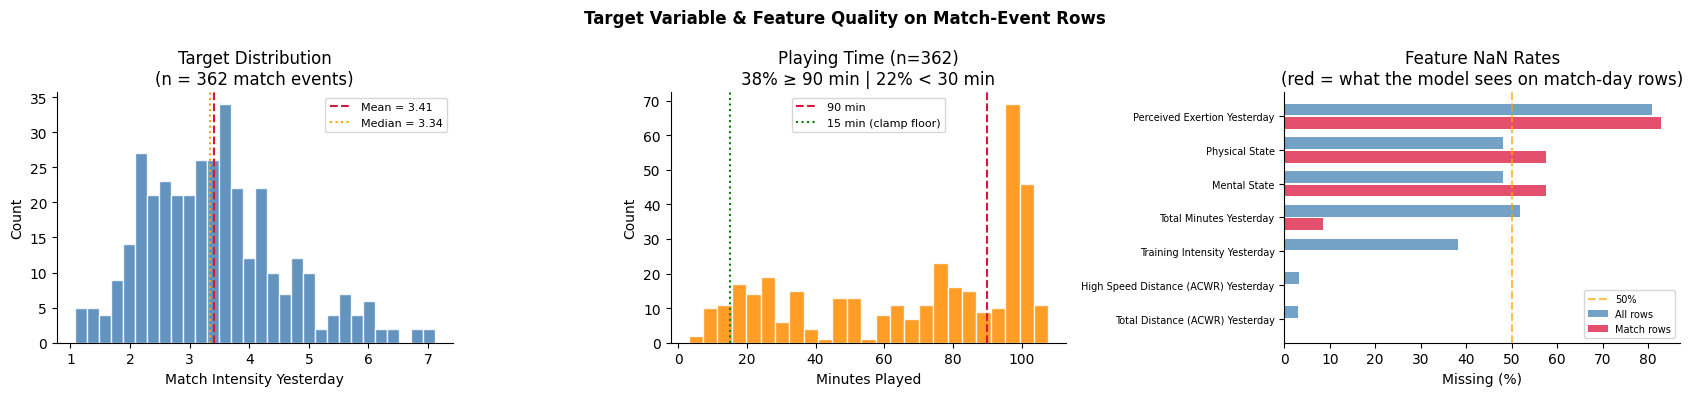


=== Feature NaN Rates ===
                                      All rows  Match rows
Total Distance (ACWR) Yesterday            3.0         0.0
High Speed Distance (ACWR) Yesterday       3.3         0.0
Training Intensity Yesterday              38.2         0.0
Total Minutes Yesterday                   51.9         8.6
Mental State                              48.2        57.5
Physical State                            48.2        57.5
Perceived Exertion Yesterday              80.8        82.9


In [63]:
# ── EDA Part 1: Dataset scope, target distribution, playing time, NaN rates ──
RTT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'RTT.xlsx'
df = pd.read_excel(RTT_PATH)
df['Date'] = pd.to_datetime(df['Date'])

match_rows = df[df['Match Intensity Yesterday'].notna()].copy()
mi = df['Match Intensity Yesterday'].dropna()

print(f'Dataset shape:             {df.shape}')
print(f'Date range:                {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Unique players:            {df["Player ID"].nunique()}')
print(f'Total rows:                {len(df):,}')
print(f'Match-event rows (MI≠NaN): {len(match_rows):,}  ({100*len(match_rows)/len(df):.1f}% of all rows)')
print(f'Unique match dates:        {match_rows["Date"].nunique()}')
print(f'\nMatch Intensity Yesterday: mean={mi.mean():.3f}, std={mi.std():.3f}, '
      f'min={mi.min():.3f}, max={mi.max():.3f}')

# ── Figure 1: Target distribution | Playing time | NaN rates ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Target Variable & Feature Quality on Match-Event Rows',
             fontsize=12, fontweight='bold')

# 1a: Target distribution
ax = axes[0]
ax.hist(mi.values, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(mi.mean(),   color='crimson', linestyle='--', lw=1.5, label=f'Mean = {mi.mean():.2f}')
ax.axvline(mi.median(), color='orange',  linestyle=':',  lw=1.5, label=f'Median = {mi.median():.2f}')
ax.set_xlabel('Match Intensity Yesterday')
ax.set_ylabel('Count')
ax.set_title(f'Target Distribution\n(n = {len(mi)} match events)')
ax.legend(fontsize=8)

# 1b: Playing time distribution
ax = axes[1]
if 'Match Minutes Played Yesterday' in df.columns:
    mins = match_rows['Match Minutes Played Yesterday'].dropna()
    ax.hist(mins.values, bins=25, color='darkorange', edgecolor='white', alpha=0.85)
    ax.axvline(90, color='crimson', linestyle='--', lw=1.5, label='90 min')
    ax.axvline(15, color='green',   linestyle=':',  lw=1.5, label='15 min (clamp floor)')
    full_90 = (mins >= 90).mean() * 100
    sub30   = (mins < 30).mean()  * 100
    ax.set_xlabel('Minutes Played')
    ax.set_ylabel('Count')
    ax.set_title(f'Playing Time (n={len(mins)})\n{full_90:.0f}% ≥ 90 min | {sub30:.0f}% < 30 min')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'Column not found', ha='center', va='center', transform=ax.transAxes)

# 1c: NaN rates — all rows vs match-event rows only
# Exclude 'Player ID' from NaN analysis (always present)
cov_for_nan = [c for c in COVARIATES if c != 'Player ID']
ax = axes[2]
nan_all   = {c: df[c].isna().mean()*100        for c in cov_for_nan if c in df.columns}
nan_match = {c: match_rows[c].isna().mean()*100 for c in cov_for_nan if c in df.columns}
nan_df = pd.DataFrame({'All rows': nan_all, 'Match rows': nan_match}).sort_values('Match rows', ascending=True)
y_pos = np.arange(len(nan_df))
ax.barh(y_pos + 0.2, nan_df['All rows'],   0.35, label='All rows',   color='steelblue', alpha=0.75)
ax.barh(y_pos - 0.2, nan_df['Match rows'], 0.35, label='Match rows', color='crimson',   alpha=0.75)
ax.set_yticks(y_pos)
ax.set_yticklabels(nan_df.index, fontsize=7)
ax.axvline(50, color='orange', linestyle='--', alpha=0.7, label='50%')
ax.set_xlabel('Missing (%)')
ax.set_title('Feature NaN Rates\n(red = what the model sees on match-day rows)')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print('\n=== Feature NaN Rates ===')
print(nan_df.round(1).to_string())

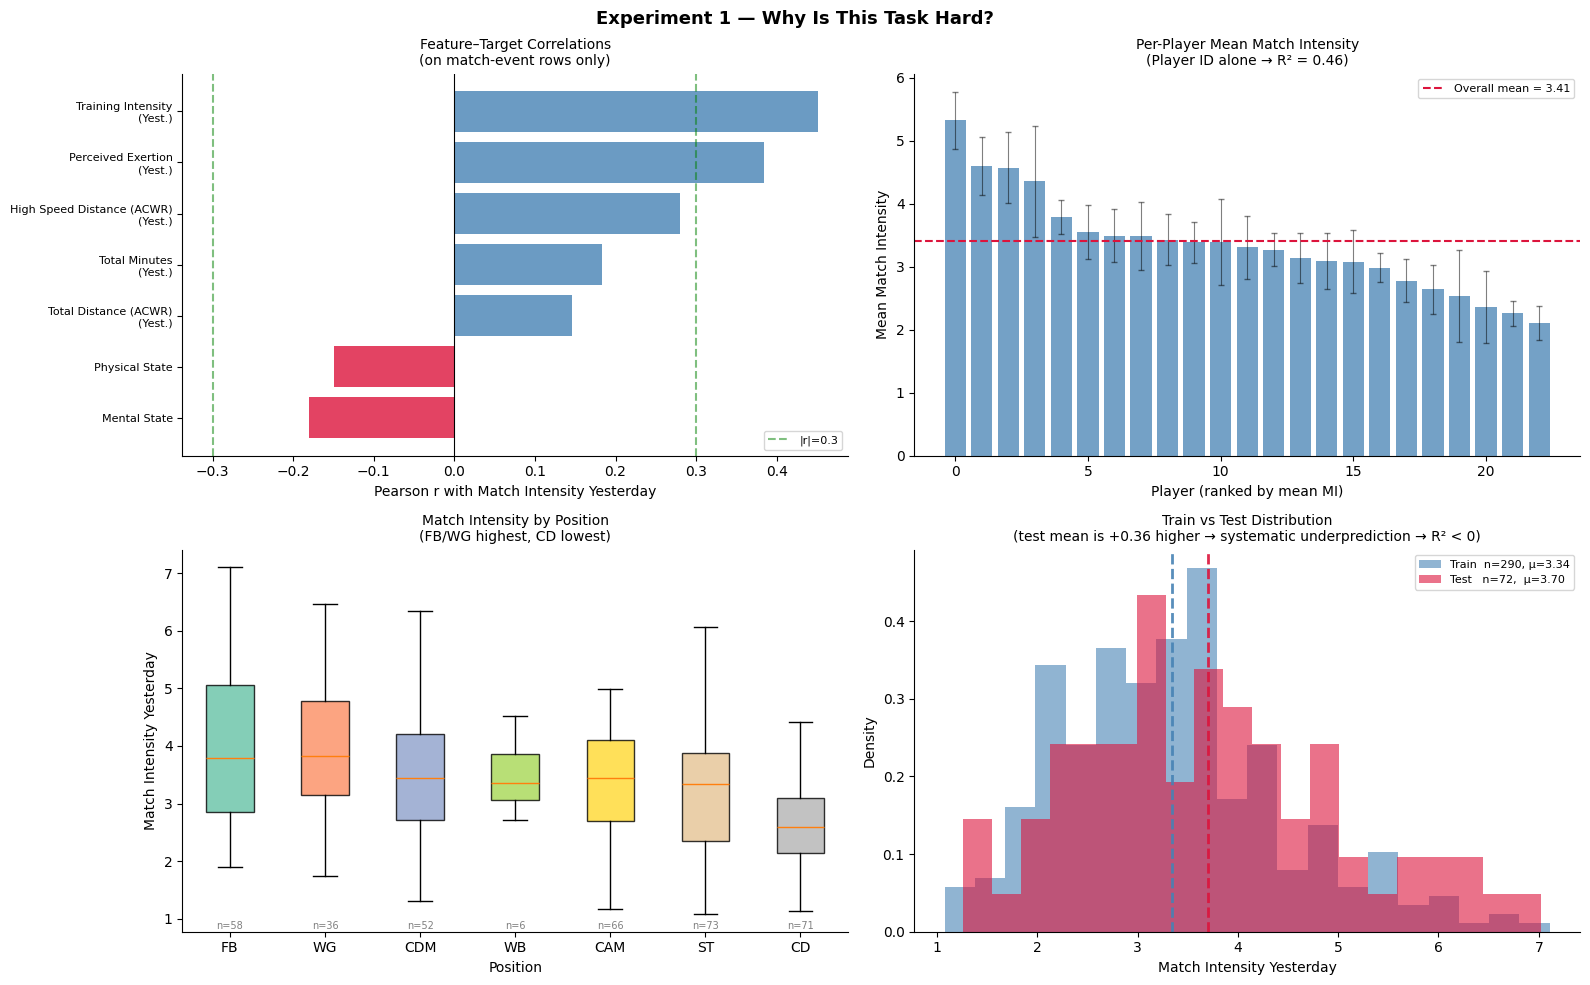


=== Root Cause Summary ===
1. Physical State NaN on match rows:       57%
   Mental State NaN on match rows:         57%
   Perceived Exertion NaN on match rows:   83%
2. Best feature correlation (abs):         |r| = 0.451  (Training Intensity Yesterday)
3. Player fixed-effect R²:                 0.455
4. Train/test mean shift:                  +0.363 MI units  (test is higher)
5. Test set: 5 match dates out of 25 total


In [64]:
# ── EDA Part 2: Correlations | Player effects | Position | Distribution shift ─
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Experiment 1 — Why Is This Task Hard?', fontsize=13, fontweight='bold')

# 2a: Feature–target correlations on match-event rows
ax = axes[0, 0]
cov_for_corr = [c for c in COVARIATES if c != 'Player ID']
corrs = {}
for col in cov_for_corr:
    if col in match_rows.columns:
        sub = match_rows[['Match Intensity Yesterday', col]].dropna()
        if len(sub) > 5:
            corrs[col] = sub['Match Intensity Yesterday'].corr(sub[col])
corr_s = pd.Series(corrs).sort_values()
bar_colors = ['crimson' if v < 0 else 'steelblue' for v in corr_s.values]
ax.barh(range(len(corr_s)), corr_s.values, color=bar_colors, alpha=0.8)
ax.set_yticks(range(len(corr_s)))
ax.set_yticklabels([c.replace(' Yesterday', '\n(Yest.)') for c in corr_s.index], fontsize=8)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(0.3,  color='green', linestyle='--', alpha=0.5, label='|r|=0.3')
ax.axvline(-0.3, color='green', linestyle='--', alpha=0.5)
ax.set_xlabel('Pearson r with Match Intensity Yesterday')
ax.set_title('Feature–Target Correlations\n(on match-event rows only)', fontsize=10)
ax.legend(fontsize=8)

# 2b: Per-player mean match intensity — player fixed effects
ax = axes[0, 1]
p_agg = match_rows.groupby('Player ID')['Match Intensity Yesterday'].agg(['mean', 'std', 'count'])
p_agg = p_agg.sort_values('mean', ascending=False)
se = p_agg['std'] / np.sqrt(p_agg['count'])
ax.bar(range(len(p_agg)), p_agg['mean'].values, color='steelblue', alpha=0.75)
ax.errorbar(range(len(p_agg)), p_agg['mean'].values, yerr=1.96 * se.values,
            fmt='none', color='black', alpha=0.5, capsize=2, lw=0.8)
overall_mean = match_rows['Match Intensity Yesterday'].mean()
ax.axhline(overall_mean, color='crimson', linestyle='--', lw=1.5,
           label=f'Overall mean = {overall_mean:.2f}')
# Compute R² from player identity alone
player_mean_map = p_agg['mean'].to_dict()
y_true_all = match_rows['Match Intensity Yesterday'].values
y_hat_player = match_rows['Player ID'].map(player_mean_map).values
valid = ~np.isnan(y_hat_player)
ss_res = np.sum((y_true_all[valid] - y_hat_player[valid]) ** 2)
ss_tot = np.sum((y_true_all[valid] - y_true_all[valid].mean()) ** 2)
r2_player = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
ax.set_xlabel('Player (ranked by mean MI)')
ax.set_ylabel('Mean Match Intensity')
ax.set_title(f'Per-Player Mean Match Intensity\n(Player ID alone → R² = {r2_player:.2f})', fontsize=10)
ax.legend(fontsize=8)

# 2c: Position effect
ax = axes[1, 0]
if 'Position' in match_rows.columns:
    pos_data = match_rows.dropna(subset=['Position', 'Match Intensity Yesterday'])
    pos_means = pos_data.groupby('Position')['Match Intensity Yesterday'].mean().sort_values(ascending=False)
    pos_order = pos_means.index.tolist()
    pos_vals = [pos_data[pos_data['Position'] == p]['Match Intensity Yesterday'].values for p in pos_order]
    bp = ax.boxplot(pos_vals, labels=pos_order, patch_artist=True)
    palette = plt.cm.Set2(np.linspace(0, 1, len(pos_order)))
    for patch, c in zip(bp['boxes'], palette):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax.set_xlabel('Position')
    ax.set_ylabel('Match Intensity Yesterday')
    ax.set_title('Match Intensity by Position\n(FB/WG highest, CD lowest)', fontsize=10)
    for i, pos in enumerate(pos_order):
        n = (pos_data['Position'] == pos).sum()
        ax.text(i + 1, ax.get_ylim()[0] + 0.05, f'n={n}', ha='center', fontsize=7, color='grey')

# 2d: Train vs test distribution shift
ax = axes[1, 1]
match_dates_sorted = sorted(match_rows['Date'].unique())
n_test_dates = max(1, int(len(match_dates_sorted) * 0.2))
test_dates = set(match_dates_sorted[-n_test_dates:])
train_mi = match_rows[~match_rows['Date'].isin(test_dates)]['Match Intensity Yesterday'].dropna()
test_mi  = match_rows[ match_rows['Date'].isin(test_dates)]['Match Intensity Yesterday'].dropna()
ax.hist(train_mi.values, bins=20, alpha=0.6, color='steelblue', density=True,
        label=f'Train  n={len(train_mi)}, μ={train_mi.mean():.2f}')
ax.hist(test_mi.values,  bins=20, alpha=0.6, color='crimson',   density=True,
        label=f'Test   n={len(test_mi)},  μ={test_mi.mean():.2f}')
ax.axvline(train_mi.mean(), color='steelblue', linestyle='--', lw=2, alpha=0.9)
ax.axvline(test_mi.mean(),  color='crimson',   linestyle='--', lw=2, alpha=0.9)
shift = test_mi.mean() - train_mi.mean()
ax.set_xlabel('Match Intensity Yesterday')
ax.set_ylabel('Density')
ax.set_title(
    f'Train vs Test Distribution\n(test mean is {shift:+.2f} higher → systematic underprediction → R² < 0)',
    fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n=== Root Cause Summary ===')
print(f'1. Physical State NaN on match rows:       {nan_match.get("Physical State", 0):.0f}%')
print(f'   Mental State NaN on match rows:         {nan_match.get("Mental State", 0):.0f}%')
print(f'   Perceived Exertion NaN on match rows:   {nan_match.get("Perceived Exertion Yesterday", 0):.0f}%')
print(f'2. Best feature correlation (abs):         |r| = {corr_s.abs().max():.3f}  ({corr_s.abs().idxmax()})')
print(f'3. Player fixed-effect R²:                 {r2_player:.3f}')
print(f'4. Train/test mean shift:                  {shift:+.3f} MI units  (test is higher)')
print(f'5. Test set: {n_test_dates} match dates out of {len(match_dates_sorted)} total')

---
## § 1 — Experiment B: Predicting Match Intensity Personal Deviation

**Objective:** Predict *how far above or below their personal average* a player performs on a given match day.

**Target:** `Match Intensity Personal Deviation` (`target_horizon=0`).

$$\text{Deviation}_t = \text{Match Intensity}_t - \text{Match Intensity Personal Average}_{t}$$

where **Match Intensity Personal Average** is the expanding mean of all prior match intensities for that player (computed before today's match). The deviation is only filled on match days where the player participated **and** has at least one prior match in the dataset.

**Why predict deviation instead of absolute intensity?**
- Absolute match intensity varies enormously *between* players (central defenders vs. wingers, starters vs. rotation players). This between-player variance dominates the signal and is not actionable by coaching staff.
- Deviation isolates *within-player* fluctuations around each player's own baseline — the part that is actually explained by recent training load and morning wellness.
- A positive deviation means the player performed above their own historical average; negative = below.

**Key differences from Experiment A (§ 2–§ 6 below):**

| | Experiment A | Experiment B (this section) |
|---|---|---|
| Target | `Match Intensity Yesterday` (absolute) | `Match Intensity Personal Deviation` (relative) |
| `target_horizon` | 1 (row after match day) | 0 (match day itself) |
| Sample size | ~3,400 non-NaN rows | ~600 match-day participant rows |
| Between-player variance | High (drives most signal) | Removed by construction |
| Main challenge | Near-zero feature–target correlation | Very small effective sample |

**Covariates:** Same as Experiment A, plus `Match Intensity Personal Average` (the player's rolling baseline — the denominator of the deviation).

> ⚠️ **Small-data warning.** After lag construction and NaN filtering, the test set contains only ~80–120 rows. All numerical results should be treated as exploratory. Focus on directional consistency across lags and model types rather than absolute metric values.


In [65]:
# ── § 1 — Match Intensity Personal Deviation: All Models × All Lags ─────────
# Target  : 'Match Intensity Personal Deviation'  (target_horizon=0)
#   = current match intensity − player's expanding-mean baseline
#   Filled only on match days where the player participated AND has ≥1 prior match.
#
# run_experiment() forwards extra kwargs to the model constructor, which passes
# them to the data loader. Overriding target_variable and target_horizon here
# is safe — they overwrite the Experiment A defaults in _build_model().
#
# Covariates: same as Experiment A + 'Match Intensity Personal Average'
# (the rolling baseline that defines the deviation — highly informative prior).
#
# ⚠ Dataset is very small (~600 match-day rows total, ~80–120 test rows).
# Results are noisy; look for consistent directional patterns across lags/models.

COVARIATES_DEV = COVARIATES + ['Match Intensity Personal Average']

dev_model_types = {
    'LinReg':   'lin_reg',
    'XGBoost':  'xgboost',
    'CatBoost': 'catboost',
    'TabPFN':   'tabpfn',
}
dev_results = {name: {} for name in dev_model_types}

for model_name, model_type in dev_model_types.items():
    print(f'\n{"="*62}')
    print(f'  {model_name} — Match Intensity Personal Deviation')
    print(f'{"="*62}')
    for lag in LAGS:
        try:
            r = run_experiment(
                covariates=COVARIATES_DEV,
                lag=lag,
                model_type=model_type,
                target_variable='Match Intensity Personal Deviation',
                target_horizon=0,   # deviation lives on the match day itself
                test_size=0.2,
                val_size=0.1,
                verbose=False,
            )
            dev_results[model_name][lag] = r
            m = r['metrics']
            flag = '✓' if m['rmse'] < m['null_rmse'] else '✗'
            print(f'  lag={lag:2d} {flag}  RMSE={m["rmse"]:.4f}  '
                  f'Null={m["null_rmse"]:.4f}  R²={m["r2"]:+.3f}  '
                  f'Pearson r={m["pearson_r"]:+.3f}  N={m["n_test"]}')
        except Exception as e:
            dev_results[model_name][lag] = None
            print(f'  lag={lag:2d} ✗  ERROR: {e}')
    print()



  LinReg — Match Intensity Personal Deviation
  lag= 1 ✗  RMSE=0.9556  Null=0.9350  R²=-0.083  Pearson r=-0.049  N=72
  lag= 2 ✗  RMSE=0.9644  Null=0.9350  R²=-0.103  Pearson r=-0.086  N=72
  lag= 3 ✗  RMSE=1.0708  Null=0.9350  R²=-0.360  Pearson r=+0.099  N=72
  lag= 4 ✗  RMSE=0.9722  Null=0.9350  R²=-0.121  Pearson r=-0.075  N=72
  lag= 5 ✗  RMSE=0.9708  Null=0.9350  R²=-0.118  Pearson r=-0.050  N=72
  lag= 6 ✗  RMSE=1.0748  Null=0.9350  R²=-0.370  Pearson r=+0.177  N=72
  lag= 7 ✗  RMSE=1.1153  Null=0.9350  R²=-0.475  Pearson r=+0.152  N=72
  lag= 8 ✗  RMSE=1.1907  Null=0.9350  R²=-0.681  Pearson r=+0.119  N=72
  lag= 9 ✗  RMSE=0.9864  Null=0.9350  R²=-0.154  Pearson r=-0.064  N=72
  lag=10 ✗  RMSE=0.9782  Null=0.9350  R²=-0.135  Pearson r=-0.029  N=72


  XGBoost — Match Intensity Personal Deviation
  lag= 1 ✗  RMSE=0.9486  Null=0.9350  R²=-0.067  Pearson r=+0.114  N=72
  lag= 2 ✗  RMSE=0.9450  Null=0.9350  R²=-0.059  Pearson r=-0.123  N=72
  lag= 3 ✗  RMSE=0.9664  Null=0.9350  R²

=== § 1 — Deviation Prediction: Full Results ===
   Model  Lag   RMSE  Null RMSE      R²  Pearson r  N test  Beats Null
CatBoost    1 0.9458      0.935 -0.0609     0.0234      72       False
CatBoost    2 0.9359      0.935 -0.0388     0.0569      72       False
CatBoost    3 0.9768      0.935 -0.1316    -0.0514      72       False
CatBoost    4 1.0006      0.935 -0.1873    -0.0731      72       False
CatBoost    5 0.9950      0.935 -0.1742    -0.0601      72       False
CatBoost    6 0.9794      0.935 -0.1374    -0.1399      72       False
CatBoost    7 1.0483      0.935 -0.3031    -0.0738      72       False
CatBoost    8 0.9780      0.935 -0.1344    -0.1056      72       False
CatBoost    9 1.0175      0.935 -0.2277    -0.1022      72       False
CatBoost   10 0.9603      0.935 -0.0937     0.0237      72       False
  LinReg    1 0.9556      0.935 -0.0829    -0.0494      72       False
  LinReg    2 0.9644      0.935 -0.1030    -0.0863      72       False
  LinReg    3 1.0708      0.

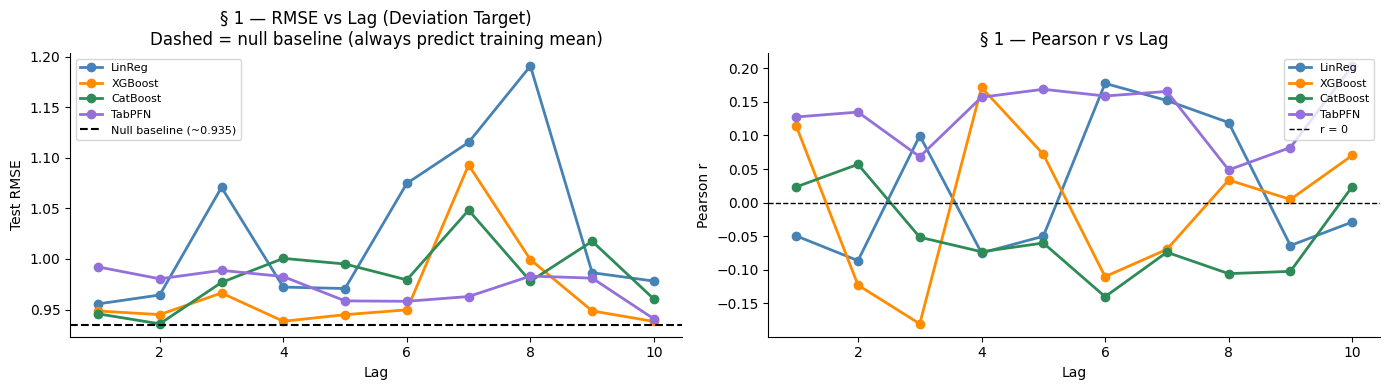


────────────────────────────────────────────────────────────
Interpretation:
  0/40 model-lag combinations beat the null baseline.
  Null RMSE ≈ std(deviation) — i.e. predicting the mean is as good as
  predicting zero deviation for every match.
  RMSE < Null RMSE: the model extracts genuine within-player signal.
  R² < 0: model is worse than a constant predictor (common for sparse data).
  Compare with Experiment A (§ 2–§ 6): absolute intensity vs deviation.
────────────────────────────────────────────────────────────


In [66]:
# ── § 1 — Deviation Summary: RMSE vs Lag + best-lag table ───────────────────
dev_rows = []
for model_name, res_by_lag in dev_results.items():
    for lag, r in res_by_lag.items():
        if r is None:
            continue
        m = r['metrics']
        dev_rows.append({
            'Model': model_name,
            'Lag': lag,
            'RMSE': round(m['rmse'], 4),
            'Null RMSE': round(m['null_rmse'], 4),
            'R²': round(m['r2'], 4),
            'Pearson r': round(m['pearson_r'], 4),
            'N test': m['n_test'],
            'Beats Null': m['rmse'] < m['null_rmse'],
        })

if not dev_rows:
    print("No results to summarise.")
else:
    dev_summary_df = pd.DataFrame(dev_rows).sort_values(['Model', 'Lag']).reset_index(drop=True)

    dev_best = (
        dev_summary_df
        .loc[dev_summary_df.groupby('Model')['RMSE'].idxmin()]
        [['Model', 'Lag', 'RMSE', 'Null RMSE', 'R²', 'Pearson r', 'N test']]
        .sort_values('RMSE')
        .reset_index(drop=True)
    )

    print('=== § 1 — Deviation Prediction: Full Results ===')
    print(dev_summary_df.to_string(index=False))
    print('\n=== Best Lag per Model (lowest Test RMSE) ===')
    print(dev_best.to_string(index=False))

    # ── RMSE vs Lag + Pearson r vs Lag ───────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    null_vals_by_model = {}
    for model_name, res_by_lag in dev_results.items():
        lags_ok = sorted(l for l, r in res_by_lag.items() if r is not None)
        if not lags_ok:
            continue
        rmses  = [dev_results[model_name][l]['metrics']['rmse']      for l in lags_ok]
        pr     = [dev_results[model_name][l]['metrics']['pearson_r']  for l in lags_ok]
        nulls  = [dev_results[model_name][l]['metrics']['null_rmse']  for l in lags_ok]
        null_vals_by_model[model_name] = np.mean(nulls)
        col = MODEL_PALETTE.get(model_name, 'gray')
        ax1.plot(lags_ok, rmses, marker='o', label=model_name, color=col, linewidth=2)
        ax2.plot(lags_ok, pr,    marker='o', label=model_name, color=col, linewidth=2)

    if null_vals_by_model:
        null_mean = np.mean(list(null_vals_by_model.values()))
        ax1.axhline(null_mean, color='black', linestyle='--', linewidth=1.5,
                    label=f'Null baseline (~{null_mean:.3f})')
    ax2.axhline(0, color='black', linestyle='--', linewidth=1, label='r = 0')

    ax1.set(xlabel='Lag', ylabel='Test RMSE',
            title='§ 1 — RMSE vs Lag (Deviation Target)\n'
                  'Dashed = null baseline (always predict training mean)')
    ax2.set(xlabel='Lag', ylabel='Pearson r',
            title='§ 1 — Pearson r vs Lag')
    for ax in (ax1, ax2):
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Interpretation ────────────────────────────────────────────────────────
    n_beats = sum(1 for r in dev_rows if r['Beats Null'])
    print(f'\n{"─"*60}')
    print(f'Interpretation:')
    print(f'  {n_beats}/{len(dev_rows)} model-lag combinations beat the null baseline.')
    print(f'  Null RMSE ≈ std(deviation) — i.e. predicting the mean is as good as')
    print(f'  predicting zero deviation for every match.')
    print(f'  RMSE < Null RMSE: the model extracts genuine within-player signal.')
    print(f'  R² < 0: model is worse than a constant predictor (common for sparse data).')
    print(f'  Compare with Experiment A (§ 2–§ 6): absolute intensity vs deviation.')
    print(f'{"─"*60}')


---
## § 2 — Linear Regression (Ridge)

L2-regularised linear model. Regularisation strength `alpha` is optimised with Optuna (50 trials, log-scale 1e-4 → 1e3). All features are z-score normalised before fitting since Ridge is scale-sensitive. Categorical features are one-hot encoded. Provides a fast, interpretable linear baseline.


In [67]:
linreg_results = {}

for lag in LAGS:
    print(f'\n── Linear Regression  lag={lag} ──')
    linreg_results[lag] = run_experiment(
        covariates=COVARIATES,
        lag=lag,
        model_type='lin_reg',
        verbose=False,
    )
    m = linreg_results[lag]['metrics']
    print(f'  RMSE={m["rmse"]:.4f}  null={m["null_rmse"]:.4f}  '
          f'R²={m["r2"]:.4f}  r={m["pearson_r"]:.4f}  n={m["n_test"]}')

print('\n── Linear Regression Summary ──')
results_table(linreg_results)


── Linear Regression  lag=1 ──
  RMSE=1.3974  null=1.3820  R²=-0.1548  r=-0.0138  n=72

── Linear Regression  lag=2 ──
  RMSE=1.4030  null=1.3820  R²=-0.1641  r=-0.0720  n=72

── Linear Regression  lag=3 ──
  RMSE=1.5393  null=1.3820  R²=-0.4014  r=-0.0686  n=72

── Linear Regression  lag=4 ──
  RMSE=1.5227  null=1.3820  R²=-0.3712  r=-0.0772  n=72

── Linear Regression  lag=5 ──
  RMSE=1.3998  null=1.3820  R²=-0.1588  r=-0.0367  n=72

── Linear Regression  lag=6 ──
  RMSE=1.5518  null=1.3820  R²=-0.4243  r=0.0039  n=72

── Linear Regression  lag=7 ──
  RMSE=1.6357  null=1.3820  R²=-0.5823  r=-0.0383  n=72

── Linear Regression  lag=8 ──
  RMSE=1.6656  null=1.3820  R²=-0.6407  r=-0.0521  n=72

── Linear Regression  lag=9 ──
  RMSE=1.4043  null=1.3820  R²=-0.1663  r=-0.1163  n=72

── Linear Regression  lag=10 ──
  RMSE=1.4086  null=1.3820  R²=-0.1735  r=-0.0933  n=72

── Linear Regression Summary ──


,RMSE,Null RMSE,Train RMSE,R²,Pearson r,MAE,N test
Lag,,,,,,,
1,1.3974,1.382,0.9982,-0.1548,-0.0138,1.0963,72
2,1.4030,1.382,0.9918,-0.1641,-0.0720,1.1025,72
3,1.5393,1.382,0.9073,-0.4014,-0.0686,1.2056,72
4,1.5227,1.382,0.9020,-0.3712,-0.0772,1.1861,72
5,1.3998,1.382,0.9794,-0.1588,-0.0367,1.1012,72
6,1.5518,1.382,0.8722,-0.4243,0.0039,1.2196,72
7,1.6357,1.382,0.8321,-0.5823,-0.0383,1.2590,72
8,1.6656,1.382,0.8240,-0.6407,-0.0521,1.2922,72
9,1.4043,1.382,0.9540,-0.1663,-0.1163,1.1017,72


---
## § 3 — XGBoost

Gradient-boosted trees with early stopping on the validation set. Default hyperparameters (`n_estimators=100`, `max_depth=6`, `lr=0.1`). Label-encodes categoricals and does not require feature scaling. Handles non-linear interactions automatically.


In [68]:
xgb_results = {}

for lag in LAGS:
    print(f'\n── XGBoost  lag={lag} ──')
    xgb_results[lag] = run_experiment(
        covariates=COVARIATES,
        lag=lag,
        model_type='xgboost',
        verbose=False,
    )
    m = xgb_results[lag]['metrics']
    print(f'  RMSE={m["rmse"]:.4f}  null={m["null_rmse"]:.4f}  '
          f'R²={m["r2"]:.4f}  r={m["pearson_r"]:.4f}  n={m["n_test"]}')

print('\n── XGBoost Summary ──')
results_table(xgb_results)


── XGBoost  lag=1 ──
  RMSE=1.2616  null=1.3820  R²=0.0586  r=0.5035  n=72

── XGBoost  lag=2 ──
  RMSE=1.3295  null=1.3820  R²=-0.0453  r=0.3960  n=72

── XGBoost  lag=3 ──
  RMSE=1.3124  null=1.3820  R²=-0.0187  r=0.3778  n=72

── XGBoost  lag=4 ──
  RMSE=1.3453  null=1.3820  R²=-0.0704  r=0.2578  n=72

── XGBoost  lag=5 ──
  RMSE=1.2957  null=1.3820  R²=0.0071  r=0.3960  n=72

── XGBoost  lag=6 ──
  RMSE=1.3244  null=1.3820  R²=-0.0373  r=0.3382  n=72

── XGBoost  lag=7 ──
  RMSE=1.3445  null=1.3820  R²=-0.0691  r=0.2789  n=72

── XGBoost  lag=8 ──
  RMSE=1.3848  null=1.3820  R²=-0.1342  r=0.1493  n=72

── XGBoost  lag=9 ──
  RMSE=1.3810  null=1.3820  R²=-0.1279  r=-0.0277  n=72

── XGBoost  lag=10 ──
  RMSE=1.3262  null=1.3820  R²=-0.0402  r=0.2704  n=72

── XGBoost Summary ──


,RMSE,Null RMSE,Train RMSE,R²,Pearson r,MAE,N test
Lag,,,,,,,
1,1.2616,1.382,0.1827,0.0586,0.5035,0.9987,72
2,1.3295,1.382,0.2820,-0.0453,0.3960,1.0547,72
3,1.3124,1.382,0.1676,-0.0187,0.3778,1.0471,72
4,1.3453,1.382,0.2201,-0.0704,0.2578,1.0645,72
5,1.2957,1.382,0.1186,0.0071,0.3960,1.0167,72
6,1.3244,1.382,0.2825,-0.0373,0.3382,1.0427,72
7,1.3445,1.382,0.2249,-0.0691,0.2789,1.0593,72
8,1.3848,1.382,0.3721,-0.1342,0.1493,1.0641,72
9,1.3810,1.382,0.9671,-0.1279,-0.0277,1.0802,72


---
## § 4 — CatBoost

Gradient-boosted trees with native categorical handling. Passes `Player ID`, `Activity Type Yesterday`, `Position`, etc. directly as `cat_features` — no encoding artefacts, no ordinal assumptions. Automatic overfitting detection via internal validation. Hyperparameters tuned with Optuna (50 trials).


In [69]:
cat_results = {}

for lag in LAGS:
    print(f'\n── CatBoost  lag={lag} ──')
    cat_results[lag] = run_experiment(
        covariates=COVARIATES,
        lag=lag,
        model_type='catboost',
        verbose=False,
    )
    m = cat_results[lag]['metrics']
    print(f'  RMSE={m["rmse"]:.4f}  null={m["null_rmse"]:.4f}  '
          f'R²={m["r2"]:.4f}  r={m["pearson_r"]:.4f}  n={m["n_test"]}')

print('\n── CatBoost Summary ──')
results_table(cat_results)


── CatBoost  lag=1 ──
  RMSE=1.2464  null=1.3820  R²=0.0813  r=0.4769  n=72

── CatBoost  lag=2 ──
  RMSE=1.2951  null=1.3820  R²=0.0080  r=0.4610  n=72

── CatBoost  lag=3 ──
  RMSE=1.3281  null=1.3820  R²=-0.0431  r=0.3249  n=72

── CatBoost  lag=4 ──
  RMSE=1.3379  null=1.3820  R²=-0.0587  r=0.2649  n=72

── CatBoost  lag=5 ──
  RMSE=1.3440  null=1.3820  R²=-0.0684  r=0.3198  n=72

── CatBoost  lag=6 ──
  RMSE=1.3430  null=1.3820  R²=-0.0667  r=0.2814  n=72

── CatBoost  lag=7 ──
  RMSE=1.2946  null=1.3820  R²=0.0088  r=0.4188  n=72

── CatBoost  lag=8 ──
  RMSE=1.3375  null=1.3820  R²=-0.0580  r=0.2476  n=72

── CatBoost  lag=9 ──
  RMSE=1.3119  null=1.3820  R²=-0.0179  r=0.2906  n=72

── CatBoost  lag=10 ──
  RMSE=1.3551  null=1.3820  R²=-0.0860  r=0.2029  n=72

── CatBoost Summary ──


,RMSE,Null RMSE,Train RMSE,R²,Pearson r,MAE,N test
Lag,,,,,,,
1,1.2464,1.382,0.3342,0.0813,0.4769,0.9679,72
2,1.2951,1.382,0.2322,0.0080,0.4610,1.0253,72
3,1.3281,1.382,0.2040,-0.0431,0.3249,1.0136,72
4,1.3379,1.382,0.1497,-0.0587,0.2649,1.0551,72
5,1.3440,1.382,0.2558,-0.0684,0.3198,1.0426,72
6,1.3430,1.382,0.0016,-0.0667,0.2814,1.0667,72
7,1.2946,1.382,0.0656,0.0088,0.4188,1.0216,72
8,1.3375,1.382,0.4685,-0.0580,0.2476,1.0762,72
9,1.3119,1.382,0.0212,-0.0179,0.2906,1.0144,72


---
## § 5 — TabPFN

Transformer pre-trained on synthetic tabular data; performs **in-context learning** — no iterative training at `fit()` time. The training set is stored and used at inference. No HPO needed. Supports both classification and regression; task type is auto-detected from the target.


In [70]:
tabpfn_results = {}

for lag in LAGS:
    print(f'\n── TabPFN  lag={lag} ──')
    tabpfn_results[lag] = run_experiment(
        covariates=COVARIATES,
        lag=lag,
        model_type='tabpfn',
        verbose=False,
    )
    m = tabpfn_results[lag]['metrics']
    print(f'  RMSE={m["rmse"]:.4f}  null={m["null_rmse"]:.4f}  '
          f'R²={m["r2"]:.4f}  r={m["pearson_r"]:.4f}  n={m["n_test"]}')

print('\n── TabPFN Summary ──')
results_table(tabpfn_results)


── TabPFN  lag=1 ──
  RMSE=1.2109  null=1.3820  R²=0.1329  r=0.5745  n=72

── TabPFN  lag=2 ──
  RMSE=1.2201  null=1.3820  R²=0.1196  r=0.5849  n=72

── TabPFN  lag=3 ──
  RMSE=1.1592  null=1.3820  R²=0.2053  r=0.6160  n=72

── TabPFN  lag=4 ──
  RMSE=1.1755  null=1.3820  R²=0.1827  r=0.6021  n=72

── TabPFN  lag=5 ──
  RMSE=1.1705  null=1.3820  R²=0.1898  r=0.5999  n=72

── TabPFN  lag=6 ──
  RMSE=1.1755  null=1.3820  R²=0.1828  r=0.5910  n=72

── TabPFN  lag=7 ──
  RMSE=1.1763  null=1.3820  R²=0.1816  r=0.5742  n=72

── TabPFN  lag=8 ──
  RMSE=1.1725  null=1.3820  R²=0.1870  r=0.5884  n=72

── TabPFN  lag=9 ──
  RMSE=1.1727  null=1.3820  R²=0.1867  r=0.5873  n=72

── TabPFN  lag=10 ──
  RMSE=1.1716  null=1.3820  R²=0.1882  r=0.5947  n=72

── TabPFN Summary ──


,RMSE,Null RMSE,Train RMSE,R²,Pearson r,MAE,N test
Lag,,,,,,,
1,1.2109,1.382,0.5659,0.1329,0.5745,0.9334,72
2,1.2201,1.382,0.5388,0.1196,0.5849,0.9457,72
3,1.1592,1.382,0.5807,0.2053,0.6160,0.8921,72
4,1.1755,1.382,0.5907,0.1827,0.6021,0.9132,72
5,1.1705,1.382,0.6013,0.1898,0.5999,0.9000,72
6,1.1755,1.382,0.6088,0.1828,0.5910,0.9050,72
7,1.1763,1.382,0.5683,0.1816,0.5742,0.9023,72
8,1.1725,1.382,0.6090,0.1870,0.5884,0.8997,72
9,1.1727,1.382,0.5930,0.1867,0.5873,0.9011,72


---
## § 6 — Summary Comparison (Experiment A: Absolute Match Intensity)

Full results across all models and lag configurations for **Experiment A** — predicting `Match Intensity Yesterday` (absolute). The **Null RMSE** (predict the training-set mean) is the minimum bar any model must beat to be useful.


In [71]:
all_model_results = {
    'LinReg':   linreg_results,
    'XGBoost':  xgb_results,
    'CatBoost': cat_results,
    'TabPFN':   tabpfn_results,
}

rows_summary = []
for model_name, res_by_lag in all_model_results.items():
    for lag, r in res_by_lag.items():
        m = r['metrics']
        rows_summary.append({
            'Model': model_name,
            'Lag': lag,
            'RMSE': round(m['rmse'], 4),
            'Null RMSE': round(m['null_rmse'], 4),
            'Train RMSE': round(m['train_rmse'], 4),
            'R²': round(m['r2'], 4),
            'Pearson r': round(m['pearson_r'], 4),
            'MAE': round(m['mae'], 4),
            'N test': m['n_test'],
        })

summary_df = pd.DataFrame(rows_summary).sort_values(['Model', 'Lag']).reset_index(drop=True)

# Best lag per model by lowest test RMSE
best_per_model = (
    summary_df.loc[summary_df.groupby('Model')['RMSE'].idxmin()]
    [['Model', 'Lag', 'RMSE', 'Null RMSE', 'R²', 'Pearson r']]
    .sort_values('RMSE')
    .reset_index(drop=True)
)

print('=== Full Results ===')
print(summary_df.to_string(index=False))
print('\n=== Best Lag per Model (lowest Test RMSE) ===')
print(best_per_model.to_string(index=False))

=== Full Results ===
   Model  Lag   RMSE  Null RMSE  Train RMSE      R²  Pearson r    MAE  N test
CatBoost    1 1.2464      1.382      0.3342  0.0813     0.4769 0.9679      72
CatBoost    2 1.2951      1.382      0.2322  0.0080     0.4610 1.0253      72
CatBoost    3 1.3281      1.382      0.2040 -0.0431     0.3249 1.0136      72
CatBoost    4 1.3379      1.382      0.1497 -0.0587     0.2649 1.0551      72
CatBoost    5 1.3440      1.382      0.2558 -0.0684     0.3198 1.0426      72
CatBoost    6 1.3430      1.382      0.0016 -0.0667     0.2814 1.0667      72
CatBoost    7 1.2946      1.382      0.0656  0.0088     0.4188 1.0216      72
CatBoost    8 1.3375      1.382      0.4685 -0.0580     0.2476 1.0762      72
CatBoost    9 1.3119      1.382      0.0212 -0.0179     0.2906 1.0144      72
CatBoost   10 1.3551      1.382      0.1708 -0.0860     0.2029 1.0751      72
  LinReg    1 1.3974      1.382      0.9982 -0.1548    -0.0138 1.0963      72
  LinReg    2 1.4030      1.382      0.9918

---
## § 7 — Covariate Influence Analysis (TabPFN-Based)

This section conducts an **extensive investigation** into which covariates drive (or hurt) predictive performance and how feature relevance changes with lag depth. All analyses use **TabPFN** as the base model — a fast in-context learner requiring no HPO — operating on the best-lag data configuration identified in § 5.

Six complementary analyses are performed, each targeting a different aspect of feature relevance:

---

### 7.1 Permutation Feature Importance
Shuffle each feature column in the test set **25 times** and measure mean ΔRMSE vs. the unshuffled baseline.

**How to read it:**
- **Positive ΔRMSE** (bar points right): shuffling hurts performance → the feature carries genuine signal. The larger the bar, the more the model depends on that feature.
- **Negative ΔRMSE** (bar points left): shuffling *improves* performance → the feature adds noise or causes the model to overfit to its values. Consider removing it.
- **Left panel (grouped):** all lag copies of a covariate are pooled. Shows total influence per feature family with 95% CI (whiskers).
- **Right panel (per-lag-copy):** individual lag-k copies coloured by lag depth (bright plasma = shallow lag, dark = deep). Reveals how quickly a feature's influence fades as you look further back in time.

### 7.2 Leave-One-Out (LOO) Ablation
Drop the **entire group** of lag copies for one base covariate at a time, retrain TabPFN (via `run_experiment`), and measure ΔRMSE vs. the full model.

**How to read it:**
- **Positive ΔRMSE:** removing this group *hurts* performance → the group is useful. Larger = more critical.
- **Negative ΔRMSE:** removing this group *helps* → the group is adding noise to the full model.
- **Method-agreement scatter (right panel):** each point is one covariate group. Points near the diagonal mean permutation importance and LOO ablation agree — a strong signal that the feature is genuinely important (or noisy). Points far off the diagonal suggest one method is picking up a spurious pattern.

### 7.3 Greedy Forward Feature Selection
Start with **no features** and greedily add one base-covariate group at a time — whichever group most reduces test RMSE at each step.

**How to read it:**
- **RMSE curve (left):** tracks model quality as features accumulate. A steep initial drop indicates a few features dominate; flattening means additional features add little value.
- **Marginal gain bars (right):** the RMSE reduction attributed to each feature at the step it was added. Features selected early provide the largest marginal gain.
- **Natural stopping point:** identify the "elbow" in the RMSE curve — beyond this, additional features provide diminishing returns and may even hurt generalisation.

### 7.4 Player ID Contribution Across All Lags
For each lag 1–10, compare TabPFN performance **with and without `Player ID`**.

**How to read it:**
- A large **ΔRMSE (with − without Player ID)** means the model benefits strongly from knowing which player it is predicting — i.e., player-specific fixed effects dominate the predictable variance.
- If ΔRMSE ≈ 0 across all lags, the other covariates (wellness, workload) capture the between-player differences well enough that explicit player identity adds nothing.
- Interaction with lag depth: if Player ID matters more at shallow lags, it is acting as a proxy for individual-level baselines that the workload lags cannot yet reconstruct.

### 7.5 Feature × Lag Importance Heatmap
Pivot the per-lag-copy permutation importances into a **base feature × lag level** matrix and visualise as a colour-annotated seaborn heatmap.

**How to read it:**
- **Green cells:** high positive ΔRMSE — this feature at this lag depth is important.
- **Red cells:** negative ΔRMSE — this feature at this lag depth adds noise.
- **Temporal decay:** if a feature's row is green only at shallow lags (t, t-1) and grey/red for deeper lags, its information ages quickly. If it stays green across all lags, it carries durable signal.
- **Row ordering:** sorted by total importance (sum across all lags), so the most important features appear at the top.

### 7.6 Covariate Redundancy Analysis
Compute the **Pearson correlation matrix** between all base features (training data) and the **Variance Inflation Factor (VIF)** for each covariate.

**How to read it:**
- **High Pearson |r| (> 0.70) between two features:** they carry largely overlapping information. Keeping both wastes model capacity and makes importance estimates unreliable.
- **High VIF (> 10):** multicollinearity — the feature can be linearly reconstructed from others. Consider removing the higher-VIF member of a correlated pair.
- **Heatmap diagonal:** always = 1. Focus on off-diagonal blocks.
- **Note on Player ID:** VIF for the label-encoded Player ID integer reflects correlations with continuous features (e.g., position-specific load patterns), not a true ordinal relationship.

---

> **⏱ Runtime note:** Analyses 7.2, 7.3, and 7.4 each call `run_experiment` multiple times (LOO: ~8 runs, Greedy: up to 36 runs, Player ID across lags: 10 runs). Combined runtime is approximately **5–12 minutes** depending on hardware.


In [72]:
# ── § 7.1 Setup: load data with best TabPFN lag, fit model, compute permutation importance ──
import re
from src.data.data_loader import ReadinessDataLoader
from tabpfn import TabPFNRegressor

# ── Pick best TabPFN lag (lowest test RMSE from § 4) ─────────────────────────
best_tfn_lag = min(tabpfn_results, key=lambda l: tabpfn_results[l]['metrics']['rmse'])
print(f'Best TabPFN lag: {best_tfn_lag}  '
      f'(RMSE = {tabpfn_results[best_tfn_lag]["metrics"]["rmse"]:.4f})')

# ── Reload data at the best lag ───────────────────────────────────────────────
# categorical_encoding='one-hot' so Player ID → 28 binary indicator columns.
# This is the correct representation for a model like TabPFN that has no native
# categorical handling. Label encoding (0-27 integers) would be wrong because
# TabPFN sees those integers as a quasi-continuous feature and could infer
# ordinal relationships (player 4 ≈ 2 × player 2) that do not exist.
loader6 = ReadinessDataLoader()
data6 = loader6.create_dataset(
    target_variable='Match Intensity Yesterday',
    predictory_columns=COVARIATES,
    lag=best_tfn_lag,
    target_horizon=1,
    test_size=0.2,
    val_size=0.1,
    categorical_encoding='one-hot',   # ← one-hot so Player ID gets 28 binary columns
    standardize=False,
    missing_numeric='mean',
    missing_categorical='mode',
)

feat_names_raw = list(data6['feature_names'])
X_train_raw = data6['X_train'].copy()
X_test_raw  = data6['X_test'].copy()
y_train_6 = data6['y_train'].values.astype(float)
y_test_6  = data6['y_test'].values.astype(float)

# ── Drop redundant Player ID lag copies ──────────────────────────────────────
# Player ID is a static feature: it never changes for a player across rows.
# After one-hot encoding and lagging, we get columns like:
#   'Player ID_1', 'Player ID_2', ...          (lag-0, current row)
#   'Player ID_1_t-1', 'Player ID_2_t-1', ...  (lag-1 copy — identical to lag-0!)
#   'Player ID_1_t-2', ...                      (lag-2 copy — also identical)
# All lag copies are perfectly collinear with the lag-0 columns.
# Keeping them would massively inflate the feature space (28 × lag = up to 280
# columns) and confuse TabPFN with perfectly redundant features.
# Solution: keep only the lag-0 Player ID indicator columns; drop all _t-k copies.

pid_lag_cols = [
    c for c in feat_names_raw
    if re.match(r'^Player ID', c) and re.search(r'_t-\d+$', c)
]
keep_cols = [c for c in feat_names_raw if c not in pid_lag_cols]

X_train_6  = X_train_raw[keep_cols].values.astype(float)
X_test_6   = X_test_raw[keep_cols].values.astype(float)
feat_names_6 = keep_cols

print(f'\nFeatures before dropping Player ID lag copies: {len(feat_names_raw)}')
print(f'Player ID lag copies dropped:                  {len(pid_lag_cols)}')
print(f'Features after pruning:                        {len(feat_names_6)}')
print(f'\nPlayer ID columns retained (lag-0 only):')
pid_kept = [c for c in feat_names_6 if re.match(r'^Player ID', c)]
print(f'  {pid_kept[:5]} ... ({len(pid_kept)} total)')
print(f'\nData shapes:  train = {X_train_6.shape}  |  test = {X_test_6.shape}')

# ── Fit TabPFN directly (gives us the model object for permutation shuffling) ─
print('\nFitting TabPFN on training data...')
tfn_6 = TabPFNRegressor(n_estimators=4)
tfn_6.fit(X_train_6, y_train_6)

y_pred_bl_6 = tfn_6.predict(X_test_6)
bl_rmse_6   = float(np.sqrt(np.mean((y_test_6 - y_pred_bl_6) ** 2)))
null_rmse_6 = float(np.sqrt(np.mean((y_test_6 - y_train_6.mean()) ** 2)))
print(f'Baseline RMSE (all features):   {bl_rmse_6:.4f}')
print(f'Null RMSE (predict train mean): {null_rmse_6:.4f}')

# ── Helper: strip lag suffix (_t-1, _t-2 …) → base covariate name ─────────────
def base_name_6(feat: str) -> str:
    return re.sub(r'_t-\d+$', '', feat)

# ── Permutation Feature Importance (N_REPEATS = 25 shuffles per feature) ──────
N_REPEATS = 25
rng6 = np.random.default_rng(seed=42)

print(f'\nComputing permutation importance  ({N_REPEATS} repeats × {len(feat_names_6)} features) …')
perm_deltas_6 = {}   # {feature_name: [Δrmse per repeat]}

for j, feat in enumerate(feat_names_6):
    deltas = []
    for _ in range(N_REPEATS):
        X_perm = X_test_6.copy()
        X_perm[:, j] = rng6.permutation(X_perm[:, j])
        y_pp = tfn_6.predict(X_perm)
        deltas.append(float(np.sqrt(np.mean((y_test_6 - y_pp) ** 2))) - bl_rmse_6)
    perm_deltas_6[feat] = deltas

print('Done.')

# ── Group by base covariate name ──────────────────────────────────────────────
# For Player ID, the base name for all 28 one-hot columns is 'Player ID_<k>'.
# We group them under a single 'Player ID' bucket.
def base_group_6(feat: str) -> str:
    """Group Player ID one-hot columns together; strip lag suffix from others."""
    if re.match(r'^Player ID', feat):
        return 'Player ID'
    return re.sub(r'_t-\d+$', '', feat)

grouped_perm_6 = {}
for feat, deltas in perm_deltas_6.items():
    grouped_perm_6.setdefault(base_group_6(feat), []).extend(deltas)

perm_mean_6 = pd.Series(
    {bn: np.mean(v) for bn, v in grouped_perm_6.items()}
).sort_values(ascending=False)

perm_sem_6 = pd.Series(
    {bn: np.std(v) / np.sqrt(len(v)) for bn, v in grouped_perm_6.items()}
).loc[perm_mean_6.index]

# ── Text summary ──────────────────────────────────────────────────────────────
print(f'\n=== Grouped Permutation Importance (baseline RMSE = {bl_rmse_6:.4f}) ===')
print('Positive ΔRMSE → shuffling hurts performance → feature is useful')
print('Negative ΔRMSE → shuffling helps performance → feature adds noise\n')
for bn in perm_mean_6.index:
    mv  = perm_mean_6[bn]
    sem = perm_sem_6[bn]
    bar = '█' * max(0, int(abs(mv) / 0.001))
    print(f'  {bn:52s}  {mv:+.4f} ± {sem:.4f}  {bar}')


Best TabPFN lag: 3  (RMSE = 1.1592)

Features before dropping Player ID lag copies: 32
Player ID lag copies dropped:                  3
Features after pruning:                        29

Player ID columns retained (lag-0 only):
  ['Player ID'] ... (1 total)

Data shapes:  train = (248, 29)  |  test = (72, 29)

Fitting TabPFN on training data...
Baseline RMSE (all features):   1.1719
Null RMSE (predict train mean): 1.3820

Computing permutation importance  (25 repeats × 29 features) …
Done.

=== Grouped Permutation Importance (baseline RMSE = 1.1719) ===
Positive ΔRMSE → shuffling hurts performance → feature is useful
Negative ΔRMSE → shuffling helps performance → feature adds noise

  Player ID                                             +0.3245 ± 0.0124  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

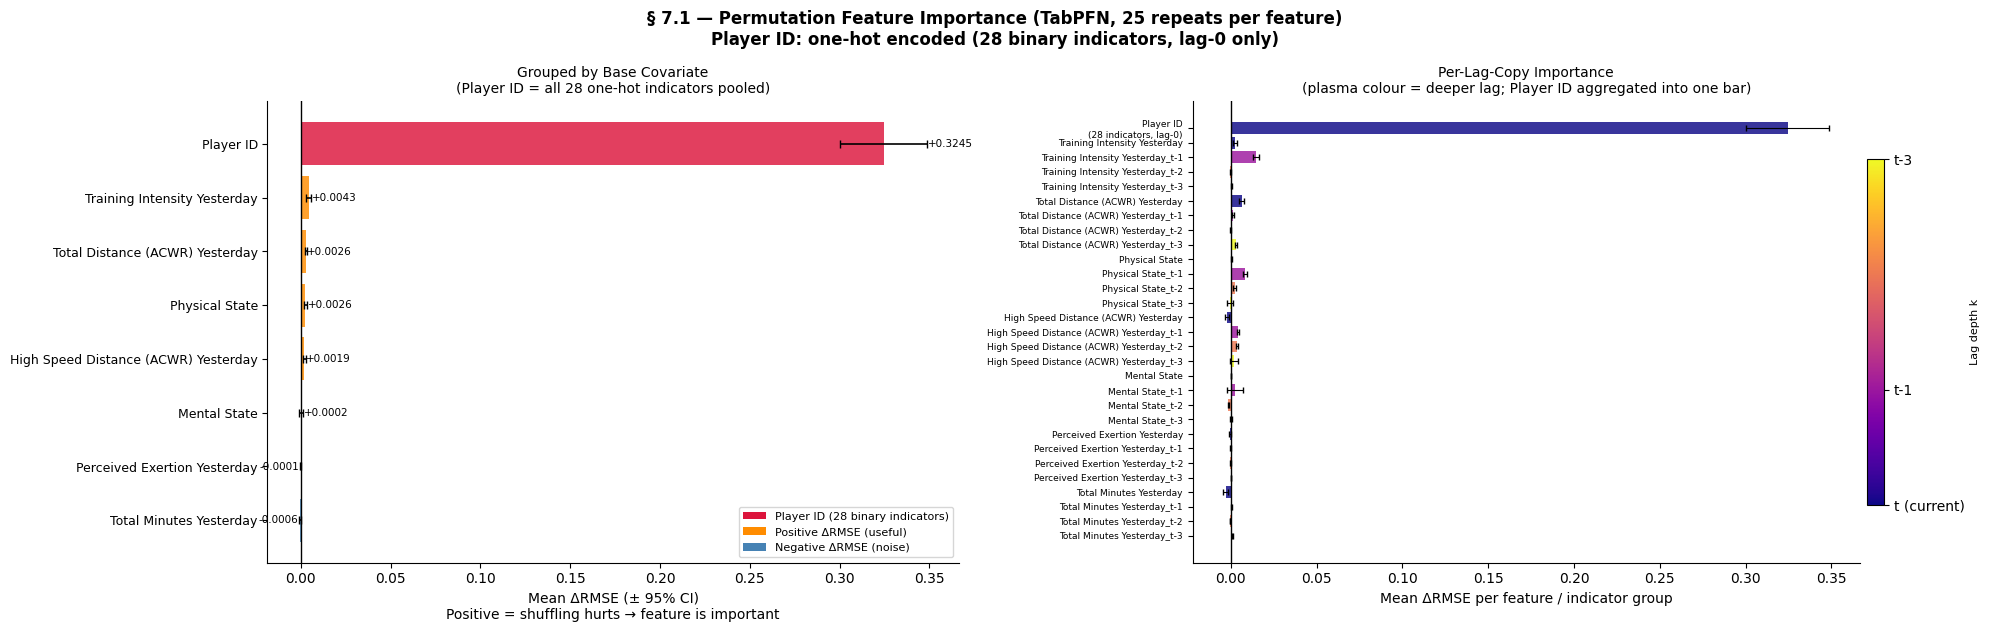

In [73]:
# ── § 7.1 Visualization: Grouped + Per-Lag-Copy Permutation Importance ────────
fig, axes = plt.subplots(1, 2, figsize=(20, max(6, len(perm_mean_6) * 0.55 + 2)))
fig.suptitle('§ 7.1 — Permutation Feature Importance (TabPFN, 25 repeats per feature)\n'
             'Player ID: one-hot encoded (28 binary indicators, lag-0 only)',
             fontsize=12, fontweight='bold')

# ── Left panel: Grouped bar chart with 95% CI ─────────────────────────────────
ax = axes[0]
means_g = perm_mean_6.values
ci95_g  = 1.96 * perm_sem_6.values
y_pos_g = np.arange(len(perm_mean_6))

bar_cols_g = ['crimson'    if 'Player ID' in bn
              else ('darkorange' if mv >= 0 else 'steelblue')
              for bn, mv in perm_mean_6.items()]

ax.barh(y_pos_g, means_g[::-1], xerr=ci95_g[::-1],
        color=bar_cols_g[::-1], alpha=0.82,
        error_kw=dict(ecolor='black', capsize=3, lw=1.2))
ax.set_yticks(y_pos_g)
ax.set_yticklabels(list(perm_mean_6.index[::-1]), fontsize=9)
ax.axvline(0, color='black', lw=1)

for i, (mv, ci) in enumerate(zip(means_g[::-1], ci95_g[::-1])):
    offset = ci + 0.0003
    ax.text(mv + offset if mv >= 0 else mv - offset, i,
            f'{mv:+.4f}', va='center', ha='left' if mv >= 0 else 'right', fontsize=7.5)

ax.set_xlabel('Mean ΔRMSE (± 95% CI)\n'
              'Positive = shuffling hurts → feature is important')
ax.set_title('Grouped by Base Covariate\n'
             '(Player ID = all 28 one-hot indicators pooled)', fontsize=10)
legend_els_g = [
    Patch(facecolor='crimson',    label='Player ID (28 binary indicators)'),
    Patch(facecolor='darkorange', label='Positive ΔRMSE (useful)'),
    Patch(facecolor='steelblue',  label='Negative ΔRMSE (noise)'),
]
ax.legend(handles=legend_els_g, fontsize=8, loc='lower right')

# ── Right panel: Per-lag-copy, coloured by lag depth ──────────────────────────
# For non-Player-ID features: show individual lag copies (_t-0, _t-1, ...) coloured by depth.
# For Player ID: aggregate all 28 one-hot indicators into one bar at lag-0.
ax = axes[1]

# Identify lag levels from feature names (after dropping Player ID lag copies)
lag_levels_present = sorted({
    int(re.search(r'_t-(\d+)$', f).group(1))
    for f in feat_names_6 if re.search(r'_t-\d+$', f)
})
no_lag_feats = [f for f in feat_names_6 if not re.search(r'_t-\d+$', f)
                and not re.match(r'^Player ID', f)]   # non-lag, non-PID features

# Build ordered list: for each base name (in importance order) → lag-0, _t-1, _t-2, ...
# For 'Player ID', insert a single aggregated entry instead of 28 individual columns.
feat_order_perlag  = []   # display names
feat_mean_perlag   = []   # mean ΔRMSE
feat_ci95_perlag   = []   # 95% CI
feat_lagdepth      = []   # lag depth (for colour)

for bn in perm_mean_6.index:
    if bn == 'Player ID':
        # Aggregate all 28 indicator columns into a single entry
        pid_feats = [f for f in feat_names_6 if re.match(r'^Player ID', f)]
        all_deltas_pid = []
        for pf in pid_feats:
            all_deltas_pid.extend(perm_deltas_6[pf])
        feat_order_perlag.append('Player ID\n(28 indicators, lag-0)')
        feat_mean_perlag.append(np.mean(all_deltas_pid))
        feat_ci95_perlag.append(1.96 * np.std(all_deltas_pid) / np.sqrt(len(all_deltas_pid)))
        feat_lagdepth.append(0)   # lag-0
    else:
        # Current-row (no lag suffix) copy
        for f in no_lag_feats:
            if base_name_6(f) == bn:
                feat_order_perlag.append(f)
                feat_mean_perlag.append(np.mean(perm_deltas_6[f]))
                feat_ci95_perlag.append(1.96 * np.std(perm_deltas_6[f]) / np.sqrt(N_REPEATS))
                feat_lagdepth.append(0)
        # Lag-k copies
        for k in lag_levels_present:
            for f in feat_names_6:
                if base_name_6(f) == bn and f.endswith(f'_t-{k}'):
                    feat_order_perlag.append(f)
                    feat_mean_perlag.append(np.mean(perm_deltas_6[f]))
                    feat_ci95_perlag.append(1.96 * np.std(perm_deltas_6[f]) / np.sqrt(N_REPEATS))
                    feat_lagdepth.append(k)

cmap_lag  = plt.cm.plasma
max_lag_k = max(lag_levels_present) if lag_levels_present else 1

def lag_color_depth(depth):
    return cmap_lag(depth / max_lag_k) if max_lag_k > 0 else cmap_lag(0.05)

y_pos_f    = np.arange(len(feat_order_perlag))
bar_cols_f = [lag_color_depth(d) for d in feat_lagdepth]

ax.barh(y_pos_f, feat_mean_perlag[::-1], xerr=feat_ci95_perlag[::-1],
        color=bar_cols_f[::-1], alpha=0.82,
        error_kw=dict(ecolor='black', capsize=2, lw=0.8))
ax.set_yticks(y_pos_f)
ax.set_yticklabels(feat_order_perlag[::-1], fontsize=6.5)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Mean ΔRMSE per feature / indicator group')
ax.set_title('Per-Lag-Copy Importance\n'
             '(plasma colour = deeper lag; Player ID aggregated into one bar)', fontsize=10)

sm_lag = plt.cm.ScalarMappable(cmap=cmap_lag, norm=plt.Normalize(0, max_lag_k))
sm_lag.set_array([])
cbar = plt.colorbar(sm_lag, ax=ax, orientation='vertical', fraction=0.025, pad=0.01)
cbar.set_label('Lag depth k', fontsize=8)
cbar.set_ticks([0, max_lag_k // 2, max_lag_k])
cbar.set_ticklabels(['t (current)', f't-{max_lag_k // 2}', f't-{max_lag_k}'])

plt.tight_layout()
plt.show()


=== § 7.2 — Leave-One-Out Ablation (TabPFN, lag=3) ===

Baseline RMSE (all 8 covariates):  1.1719
Null RMSE (predict train mean):            1.3820

Dropping one base covariate at a time ...

  drop [Total Distance (ACWR) Yesterday              ]  RMSE=1.1963  Δ=+0.0245  [USEFUL]
  drop [High Speed Distance (ACWR) Yesterday         ]  RMSE=1.1816  Δ=+0.0097  [USEFUL]
  drop [Training Intensity Yesterday                 ]  RMSE=1.1563  Δ=-0.0155  [NOISE]
  drop [Perceived Exertion Yesterday                 ]  RMSE=1.1928  Δ=+0.0210  [USEFUL]
  drop [Total Minutes Yesterday                      ]  RMSE=1.1846  Δ=+0.0127  [USEFUL]
  drop [Physical State                               ]  RMSE=1.1996  Δ=+0.0277  [USEFUL]
  drop [Mental State                                 ]  RMSE=1.1690  Δ=-0.0028  [NOISE]
  drop [Player ID                                    ]  RMSE=1.3870  Δ=+0.2151  [USEFUL]


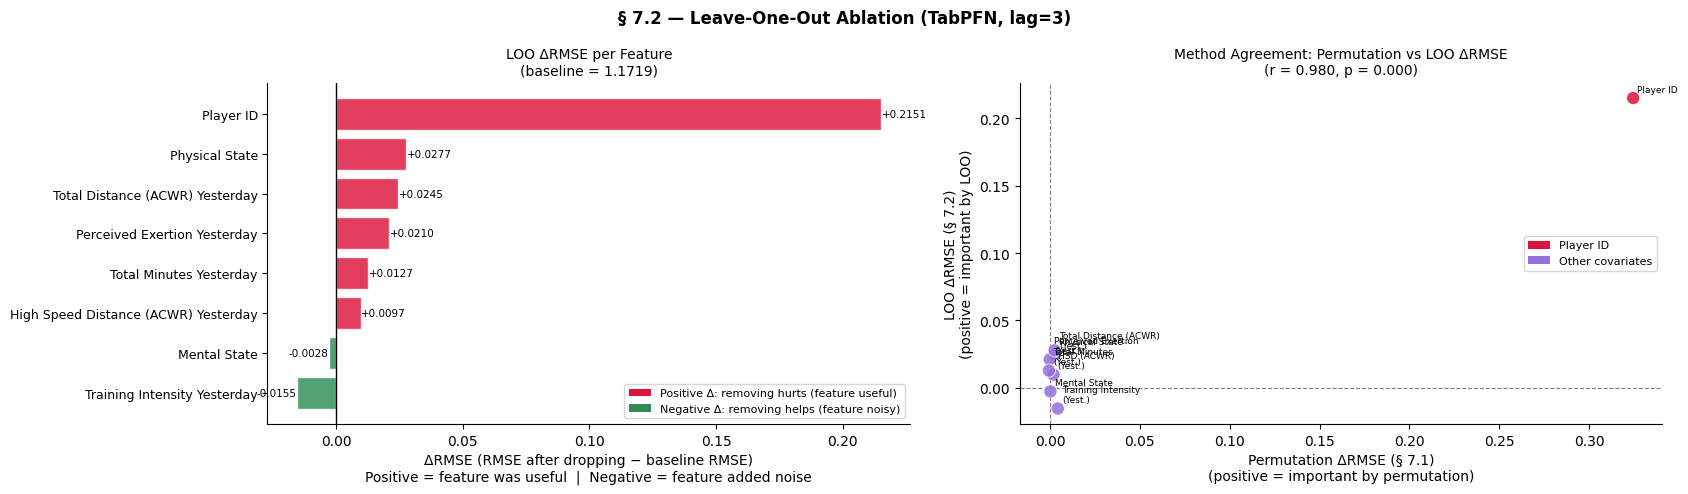


=== LOO Summary Table ===
                                        rmse   delta
Player ID                             1.3870  0.2151
Physical State                        1.1996  0.0277
Total Distance (ACWR) Yesterday       1.1963  0.0245
Perceived Exertion Yesterday          1.1928  0.0210
Total Minutes Yesterday               1.1846  0.0127
High Speed Distance (ACWR) Yesterday  1.1816  0.0097
Mental State                          1.1690 -0.0028
Training Intensity Yesterday          1.1563 -0.0155


In [74]:
# ── § 7.2 Leave-One-Out Ablation (TabPFN) ────────────────────────────────────
# Drop the entire group of lag copies for one base covariate at a time.
# Positive ΔRMSE = feature group was useful; negative = feature group added noise.
print(f'=== § 7.2 — Leave-One-Out Ablation (TabPFN, lag={best_tfn_lag}) ===\n')
print(f'Baseline RMSE (all {len(COVARIATES)} covariates):  {bl_rmse_6:.4f}')
print(f'Null RMSE (predict train mean):            {null_rmse_6:.4f}')
print(f'\nDropping one base covariate at a time ...\n')

loo_tfn = {}
for drop_cov in COVARIATES:
    remaining_loo = [c for c in COVARIATES if c != drop_cov]
    r_loo = run_experiment(
        covariates=remaining_loo,
        lag=best_tfn_lag,
        model_type='tabpfn',
        verbose=False,
    )
    loo_rmse  = r_loo['metrics']['rmse']
    delta_loo = loo_rmse - bl_rmse_6
    loo_tfn[drop_cov] = {'rmse': loo_rmse, 'delta': delta_loo}
    sign = '+' if delta_loo >= 0 else ''
    verdict = 'USEFUL'  if delta_loo > 0.001 else ('NOISE' if delta_loo < -0.001 else 'neutral')
    print(f'  drop [{drop_cov:45s}]  RMSE={loo_rmse:.4f}  Δ={sign}{delta_loo:.4f}  [{verdict}]')

loo_df = pd.DataFrame(loo_tfn).T.sort_values('delta', ascending=False)
loo_df['delta'] = loo_df['delta'].round(4)
loo_df['rmse']  = loo_df['rmse'].round(4)

# ── Figure: LOO ΔRMSE bar + method-agreement scatter ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle(f'§ 7.2 — Leave-One-Out Ablation (TabPFN, lag={best_tfn_lag})',
             fontsize=12, fontweight='bold')

# Panel A: LOO ΔRMSE bar chart
ax = axes[0]
colors_loo2 = ['crimson' if v > 0 else 'seagreen' for v in loo_df['delta'].values]
ax.barh(range(len(loo_df)), loo_df['delta'].values[::-1],
        color=colors_loo2[::-1], alpha=0.82, edgecolor='white')
ax.set_yticks(range(len(loo_df)))
ax.set_yticklabels(list(loo_df.index[::-1]), fontsize=9)
ax.axvline(0, color='black', lw=1)

# Annotate values
for i, v in enumerate(loo_df['delta'].values[::-1]):
    offset = 0.0002
    ax.text(v + (offset if v >= 0 else -offset), i, f'{v:+.4f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=7.5)

ax.set_xlabel('ΔRMSE (RMSE after dropping − baseline RMSE)\n'
              'Positive = feature was useful  |  Negative = feature added noise')
ax.set_title(f'LOO ΔRMSE per Feature\n(baseline = {bl_rmse_6:.4f})', fontsize=10)
legend_loo2 = [
    Patch(facecolor='crimson',  label='Positive Δ: removing hurts (feature useful)'),
    Patch(facecolor='seagreen', label='Negative Δ: removing helps (feature noisy)'),
]
ax.legend(handles=legend_loo2, fontsize=8)

# Panel B: Method-agreement scatter (Permutation ΔRMSE vs LOO ΔRMSE)
ax = axes[1]
common_c = [c for c in COVARIATES if c in loo_df.index and c in perm_mean_6.index]
x_perm_sc = np.array([perm_mean_6[c] for c in common_c])
y_loo_sc  = np.array([loo_df.loc[c, 'delta'] for c in common_c])

scatter_colors = ['crimson' if 'Player ID' in c else 'mediumpurple' for c in common_c]
ax.scatter(x_perm_sc, y_loo_sc, s=90, c=scatter_colors, alpha=0.85,
           edgecolors='white', linewidths=0.6, zorder=3)

for i, cov in enumerate(common_c):
    short_lbl = cov.replace(' Yesterday', '\n(Yest.)').replace('High Speed Distance', 'HSD')
    ax.annotate(short_lbl, (x_perm_sc[i], y_loo_sc[i]),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.axvline(0, color='grey', lw=0.8, linestyle='--')

if len(common_c) > 2:
    from scipy import stats as scipy_stats
    r_agree, p_agree = scipy_stats.pearsonr(x_perm_sc, y_loo_sc)
    ax.set_title(f'Method Agreement: Permutation vs LOO ΔRMSE\n'
                 f'(r = {r_agree:.3f}, p = {p_agree:.3f})', fontsize=10)
else:
    ax.set_title('Method Agreement: Permutation vs LOO ΔRMSE', fontsize=10)

ax.set_xlabel('Permutation ΔRMSE (§ 7.1)\n(positive = important by permutation)')
ax.set_ylabel('LOO ΔRMSE (§ 7.2)\n(positive = important by LOO)')

legend_sc = [
    Patch(facecolor='crimson',     label='Player ID'),
    Patch(facecolor='mediumpurple',label='Other covariates'),
]
ax.legend(handles=legend_sc, fontsize=8)

plt.tight_layout()
plt.show()

print('\n=== LOO Summary Table ===')
print(loo_df.to_string())


=== § 7.3 — Greedy Forward Feature Selection (TabPFN, lag=3) ===

Null RMSE (predict training mean):  1.3820
Full-set baseline RMSE:             1.1719

Running greedy forward selection (8 steps)...

  Step  1: Added [Player ID                                    ]  RMSE=1.1782  ΔNull=+0.2037  Δprev=+0.2037
  Step  2: Added [Perceived Exertion Yesterday                 ]  RMSE=1.1617  ΔNull=+0.2203  Δprev=+0.0166
  Step  3: Added [Total Distance (ACWR) Yesterday              ]  RMSE=1.1633  ΔNull=+0.2187  Δprev=-0.0016
  Step  4: Added [Mental State                                 ]  RMSE=1.1629  ΔNull=+0.2191  Δprev=+0.0004
  Step  5: Added [Total Minutes Yesterday                      ]  RMSE=1.1575  ΔNull=+0.2244  Δprev=+0.0054
  Step  6: Added [Physical State                               ]  RMSE=1.1541  ΔNull=+0.2279  Δprev=+0.0034
  Step  7: Added [High Speed Distance (ACWR) Yesterday         ]  RMSE=1.1390  ΔNull=+0.2429  Δprev=+0.0151
  Step  8: Added [Training Intensity Yesterd

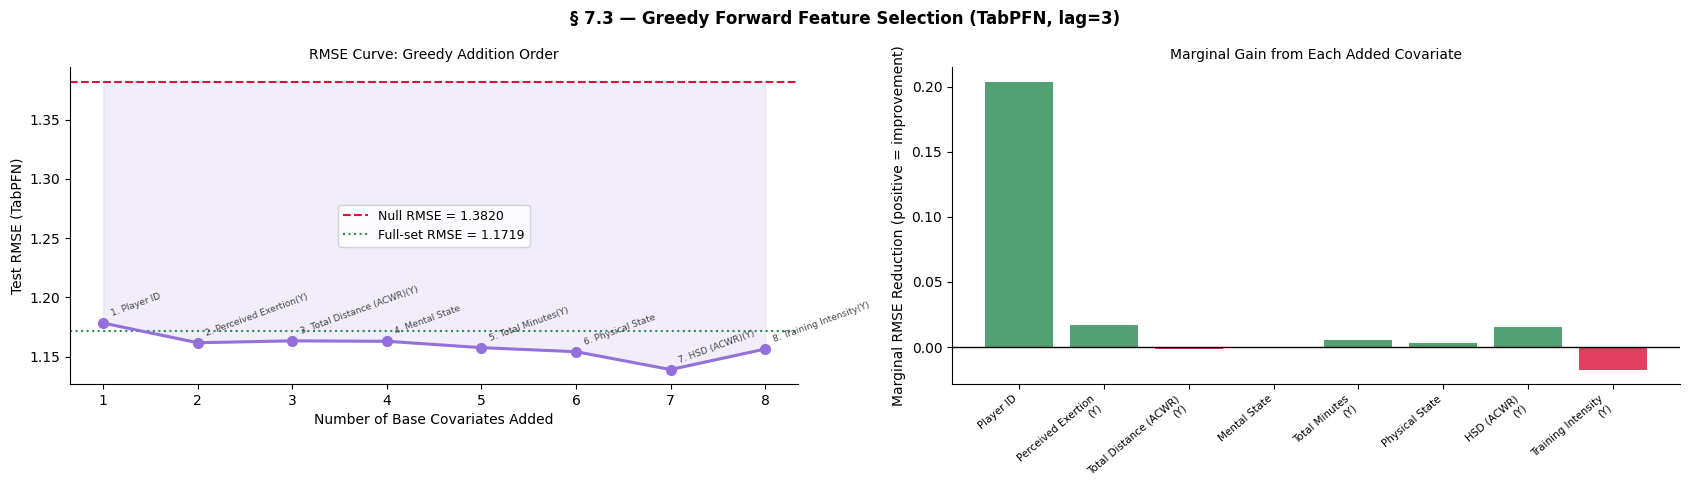


=== Greedy Addition Order (marginal gain ranking) ===
   1. Player ID                                             RMSE=1.1782  Marginal=+0.2037  Cumulative gain=+0.2037
   2. Perceived Exertion Yesterday                          RMSE=1.1617  Marginal=+0.0166  Cumulative gain=+0.2203
   3. Total Distance (ACWR) Yesterday                       RMSE=1.1633  Marginal=-0.0016  Cumulative gain=+0.2187
   4. Mental State                                          RMSE=1.1629  Marginal=+0.0004  Cumulative gain=+0.2191
   5. Total Minutes Yesterday                               RMSE=1.1575  Marginal=+0.0054  Cumulative gain=+0.2244
   6. Physical State                                        RMSE=1.1541  Marginal=+0.0034  Cumulative gain=+0.2279
   7. High Speed Distance (ACWR) Yesterday                  RMSE=1.1390  Marginal=+0.0151  Cumulative gain=+0.2429
   8. Training Intensity Yesterday                          RMSE=1.1563  Marginal=-0.0173  Cumulative gain=+0.2256


In [75]:
# ── § 7.3 Greedy Forward Feature Selection (TabPFN) ──────────────────────────
# Start empty; greedily add the base-covariate group that most reduces test RMSE.
print(f'=== § 7.3 — Greedy Forward Feature Selection (TabPFN, lag={best_tfn_lag}) ===\n')

null_rmse_greedy = float(np.sqrt(np.mean((y_test_6 - y_train_6.mean()) ** 2)))
print(f'Null RMSE (predict training mean):  {null_rmse_greedy:.4f}')
print(f'Full-set baseline RMSE:             {bl_rmse_6:.4f}')
print(f'\nRunning greedy forward selection ({len(COVARIATES)} steps)...\n')

remaining_g = list(COVARIATES)
selected_g  = []
greedy_rmse_curve = []   # RMSE after adding each covariate
greedy_order      = []   # which covariate was added at each step

while remaining_g:
    best_cov_g   = None
    best_rmse_g  = np.inf

    for cov_cand in remaining_g:
        candidate_set = selected_g + [cov_cand]
        r_cand = run_experiment(
            covariates=candidate_set,
            lag=best_tfn_lag,
            model_type='tabpfn',
            verbose=False,
        )
        if r_cand['metrics']['rmse'] < best_rmse_g:
            best_rmse_g = r_cand['metrics']['rmse']
            best_cov_g  = cov_cand

    selected_g.append(best_cov_g)
    remaining_g.remove(best_cov_g)
    greedy_rmse_curve.append(best_rmse_g)
    greedy_order.append(best_cov_g)

    delta_null = null_rmse_greedy - best_rmse_g
    delta_prev = (greedy_rmse_curve[-2] - best_rmse_g) if len(greedy_rmse_curve) > 1 else delta_null
    print(f'  Step {len(selected_g):2d}: Added [{best_cov_g:45s}]  '
          f'RMSE={best_rmse_g:.4f}  ΔNull={delta_null:+.4f}  Δprev={delta_prev:+.4f}')

# ── Plot greedy selection curve ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle(f'§ 7.3 — Greedy Forward Feature Selection (TabPFN, lag={best_tfn_lag})',
             fontsize=12, fontweight='bold')

# Panel A: RMSE curve
ax = axes[0]
steps_g = range(1, len(greedy_rmse_curve) + 1)
ax.plot(steps_g, greedy_rmse_curve, 'o-', color='mediumpurple', lw=2.2, ms=7, zorder=3)
ax.fill_between(steps_g, greedy_rmse_curve, null_rmse_greedy,
                alpha=0.12, color='mediumpurple', label='_nolegend_')
ax.axhline(null_rmse_greedy, color='crimson', linestyle='--', lw=1.5,
           label=f'Null RMSE = {null_rmse_greedy:.4f}')
ax.axhline(bl_rmse_6, color='seagreen', linestyle=':', lw=1.5,
           label=f'Full-set RMSE = {bl_rmse_6:.4f}')

# Annotate each step
for i, (s, rmse_v) in enumerate(zip(steps_g, greedy_rmse_curve)):
    short = greedy_order[i].replace(' Yesterday', '(Y)').replace('High Speed Distance', 'HSD')
    ax.annotate(f'{s}. {short}', (s, rmse_v),
                textcoords='offset points', xytext=(5, 5),
                fontsize=6.5, rotation=20, ha='left', color='#444')

ax.set_xlabel('Number of Base Covariates Added')
ax.set_ylabel('Test RMSE (TabPFN)')
ax.set_title('RMSE Curve: Greedy Addition Order', fontsize=10)
ax.set_xticks(list(steps_g))
ax.legend(fontsize=9)

# Panel B: Marginal gain per step
ax = axes[1]
marginal = np.diff([null_rmse_greedy] + list(greedy_rmse_curve)) * -1   # positive = improvement
colors_g = ['seagreen' if m > 0 else 'crimson' for m in marginal]
ax.bar(range(1, len(marginal) + 1), marginal, color=colors_g, alpha=0.82)
ax.set_xticks(range(1, len(marginal) + 1))
ax.set_xticklabels(
    [o.replace(' Yesterday', '\n(Y)').replace('High Speed Distance', 'HSD')
     for o in greedy_order],
    rotation=40, ha='right', fontsize=7.5)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Marginal RMSE Reduction (positive = improvement)')
ax.set_title('Marginal Gain from Each Added Covariate', fontsize=10)

plt.tight_layout()
plt.show()

# ── Ranked importance table ────────────────────────────────────────────────
print('\n=== Greedy Addition Order (marginal gain ranking) ===')
for i, (cov, rmse_v) in enumerate(zip(greedy_order, greedy_rmse_curve)):
    mg = marginal[i]
    cum_gain = null_rmse_greedy - rmse_v
    print(f'  {i+1:2d}. {cov:52s}  RMSE={rmse_v:.4f}  '
          f'Marginal={mg:+.4f}  Cumulative gain={cum_gain:+.4f}')


=== § 7.4 — Player ID Contribution Across All Lags (TabPFN) ===

Covariates without Player ID (7):  ['Total Distance (ACWR) Yesterday', 'High Speed Distance (ACWR) Yesterday', 'Training Intensity Yesterday', 'Perceived Exertion Yesterday', 'Total Minutes Yesterday', 'Physical State', 'Mental State']

Running TabPFN (no Player ID) for all 10 lag configurations...

  lag= 1  with PID=1.2109  no PID=1.4254  Δ=+0.2145  ✓ helpful
  lag= 2  with PID=1.2201  no PID=1.4036  Δ=+0.1835  ✓ helpful
  lag= 3  with PID=1.1592  no PID=1.3870  Δ=+0.2278  ✓ helpful
  lag= 4  with PID=1.1755  no PID=1.3927  Δ=+0.2172  ✓ helpful
  lag= 5  with PID=1.1705  no PID=1.3945  Δ=+0.2240  ✓ helpful
  lag= 6  with PID=1.1755  no PID=1.3945  Δ=+0.2190  ✓ helpful
  lag= 7  with PID=1.1763  no PID=1.3845  Δ=+0.2081  ✓ helpful
  lag= 8  with PID=1.1725  no PID=1.3969  Δ=+0.2244  ✓ helpful
  lag= 9  with PID=1.1727  no PID=1.3774  Δ=+0.2047  ✓ helpful
  lag=10  with PID=1.1716  no PID=1.4038  Δ=+0.2322  ✓ helpful


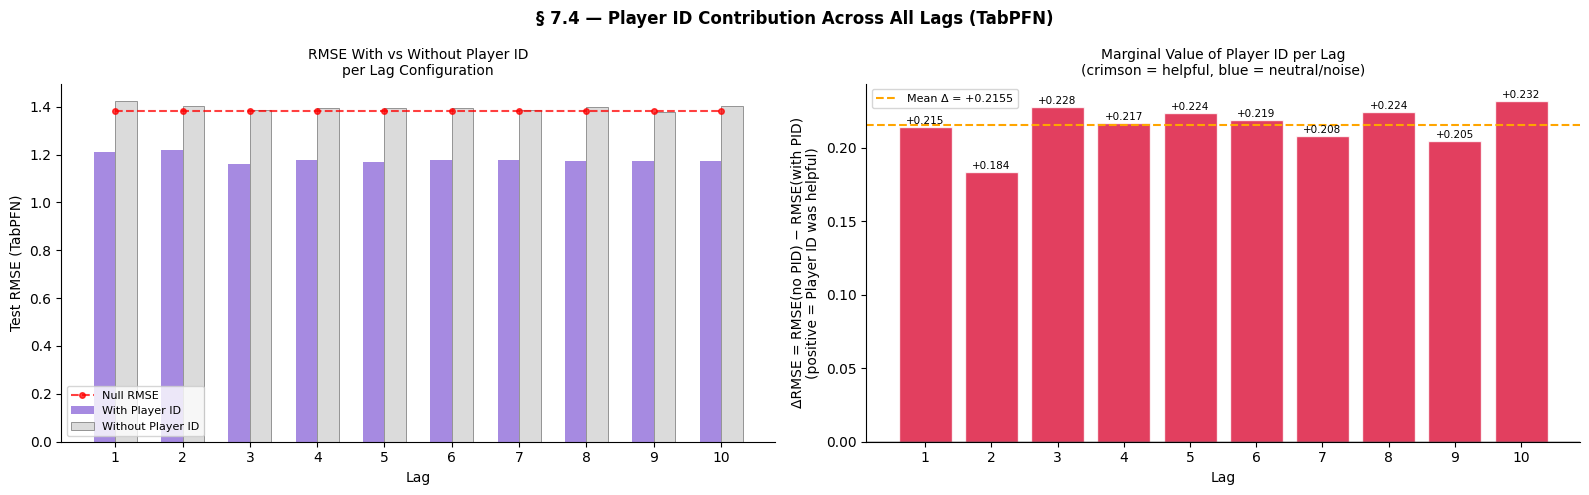


=== Player ID Contribution Summary ===
Mean ΔRMSE from adding Player ID:    +0.2155
Max  ΔRMSE (most helpful lag):       lag=10  Δ=+0.2322
Best lag with Player ID:             lag=3  RMSE=1.1592
Best lag without Player ID:          lag=9  RMSE=1.3774
Lags where Player ID helped:         10/10


In [76]:
# ── § 7.4 Player ID Contribution Across All Lags (TabPFN) ────────────────────
# For each lag 1–10, compare TabPFN RMSE with vs without Player ID.
# Uses tabpfn_results (with Player ID, all lags) already computed in § 4.
print('=== § 7.4 — Player ID Contribution Across All Lags (TabPFN) ===\n')

covs_no_pid = [c for c in COVARIATES if c != 'Player ID']
print(f'Covariates without Player ID ({len(covs_no_pid)}):  {covs_no_pid}')
print(f'\nRunning TabPFN (no Player ID) for all {len(LAGS)} lag configurations...\n')

tabpfn_no_pid_rmse = {}
for lag in LAGS:
    r_np = run_experiment(
        covariates=covs_no_pid,
        lag=lag,
        model_type='tabpfn',
        verbose=False,
    )
    tabpfn_no_pid_rmse[lag] = r_np['metrics']['rmse']
    rmse_with = tabpfn_results[lag]['metrics']['rmse']
    delta_pid = tabpfn_no_pid_rmse[lag] - rmse_with
    print(f'  lag={lag:2d}  with PID={rmse_with:.4f}  no PID={tabpfn_no_pid_rmse[lag]:.4f}  '
          f'Δ={delta_pid:+.4f}  {"✓ helpful" if delta_pid > 0 else "✗ not helpful"}')

# ── Compute arrays ────────────────────────────────────────────────────────────
lags_arr   = np.array(LAGS)
rmse_with  = np.array([tabpfn_results[l]['metrics']['rmse'] for l in LAGS])
rmse_noP   = np.array([tabpfn_no_pid_rmse[l] for l in LAGS])
null_arr   = np.array([tabpfn_results[l]['metrics']['null_rmse'] for l in LAGS])
delta_pid  = rmse_noP - rmse_with   # positive = Player ID helped

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('§ 7.4 — Player ID Contribution Across All Lags (TabPFN)',
             fontsize=12, fontweight='bold')

# Panel A: Side-by-side RMSE
ax = axes[0]
w = 0.32
ax.bar(lags_arr - w/2, rmse_with, w, label='With Player ID',    color='mediumpurple', alpha=0.82)
ax.bar(lags_arr + w/2, rmse_noP,  w, label='Without Player ID', color='lightgrey',   alpha=0.82,
       edgecolor='grey', linewidth=0.7)
ax.plot(lags_arr, null_arr, 'r--o', lw=1.5, ms=4, label='Null RMSE', alpha=0.75)
ax.set_xlabel('Lag')
ax.set_ylabel('Test RMSE (TabPFN)')
ax.set_xticks(LAGS)
ax.set_title('RMSE With vs Without Player ID\nper Lag Configuration', fontsize=10)
ax.legend(fontsize=8)

# Panel B: ΔRMSE (Player ID contribution)
ax = axes[1]
colors_dp = ['crimson' if d > 0 else 'steelblue' for d in delta_pid]
ax.bar(lags_arr, delta_pid, color=colors_dp, alpha=0.82, edgecolor='white')
ax.axhline(0, color='black', lw=1)
ax.axhline(delta_pid.mean(), color='orange', linestyle='--', lw=1.5,
           label=f'Mean Δ = {delta_pid.mean():+.4f}')
for i, (lag, d) in enumerate(zip(LAGS, delta_pid)):
    ax.text(lag, d + (0.0005 if d >= 0 else -0.0015), f'{d:+.3f}',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=7.5)
ax.set_xlabel('Lag')
ax.set_ylabel('ΔRMSE = RMSE(no PID) − RMSE(with PID)\n(positive = Player ID was helpful)')
ax.set_xticks(LAGS)
ax.set_title('Marginal Value of Player ID per Lag\n(crimson = helpful, blue = neutral/noise)', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\n=== Player ID Contribution Summary ===')
print(f'Mean ΔRMSE from adding Player ID:    {delta_pid.mean():+.4f}')
print(f'Max  ΔRMSE (most helpful lag):       lag={LAGS[int(delta_pid.argmax())]}  Δ={delta_pid.max():+.4f}')
print(f'Best lag with Player ID:             lag={LAGS[int(rmse_with.argmin())]}  RMSE={rmse_with.min():.4f}')
print(f'Best lag without Player ID:          lag={LAGS[int(rmse_noP.argmin())]}  RMSE={rmse_noP.min():.4f}')
n_helpful = (delta_pid > 0).sum()
print(f'Lags where Player ID helped:         {n_helpful}/{len(LAGS)}')


=== § 7.5 — Feature × Lag Importance Heatmap ===

Heatmap values (mean ΔRMSE per feature × lag):
                                      t\n(lag 0)     t-1     t-2     t-3
Player ID                                 0.3245     NaN     NaN     NaN
Training Intensity Yesterday              0.0027  0.0146 -0.0003  0.0004
Total Distance (ACWR) Yesterday           0.0063  0.0012 -0.0000  0.0030
Physical State                            0.0003  0.0082  0.0022 -0.0004
High Speed Distance (ACWR) Yesterday     -0.0022  0.0044  0.0036  0.0017
Mental State                              0.0001  0.0024 -0.0014 -0.0002
Perceived Exertion Yesterday             -0.0004  0.0000 -0.0002  0.0001
Total Minutes Yesterday                  -0.0031  0.0003 -0.0006  0.0009


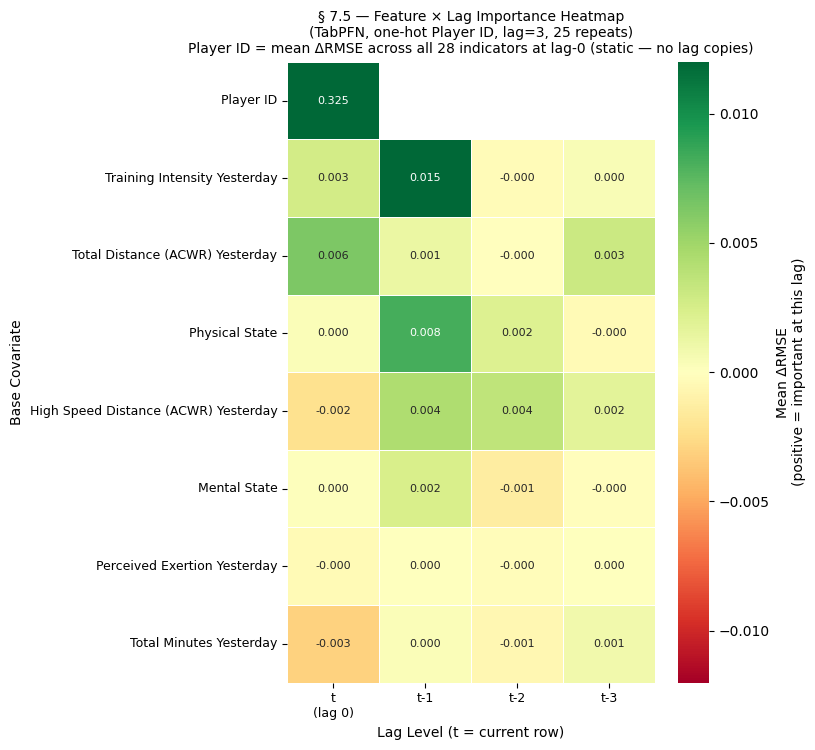


=== Best Lag per Feature (highest ΔRMSE) ===
  Player ID                                             most important at t
(lag 0) (Δ=+0.3245)  | most noisy at t
(lag 0) (Δ=+0.3245)  [static — no lag copies]
  Training Intensity Yesterday                          most important at t-1 (Δ=+0.0146)  | most noisy at t-2 (Δ=-0.0003)
  Total Distance (ACWR) Yesterday                       most important at t
(lag 0) (Δ=+0.0063)  | most noisy at t-2 (Δ=-0.0000)
  Physical State                                        most important at t-1 (Δ=+0.0082)  | most noisy at t-3 (Δ=-0.0004)
  High Speed Distance (ACWR) Yesterday                  most important at t-1 (Δ=+0.0044)  | most noisy at t
(lag 0) (Δ=-0.0022)
  Mental State                                          most important at t-1 (Δ=+0.0024)  | most noisy at t-2 (Δ=-0.0014)
  Perceived Exertion Yesterday                          most important at t-3 (Δ=+0.0001)  | most noisy at t
(lag 0) (Δ=-0.0004)
  Total Minutes Yesterday            

In [77]:
# ── § 7.5 Feature × Lag Importance Heatmap ───────────────────────────────────
# Pivot per-lag-copy permutation importances into a base_group × lag matrix.
# Player ID: all 28 one-hot indicators are aggregated under 'Player ID' at lag-0.
# Green cells = important at that lag; red cells = shuffling helps (adds noise).
print('=== § 7.5 — Feature × Lag Importance Heatmap ===\n')

# Build {base_group: {lag_k: [mean_deltas]}} — aggregate multiple features per cell
heatmap_raw = {}   # {base_group: {lag_k: [mean_delta values to average]}}
for feat, deltas in perm_deltas_6.items():
    bn    = base_group_6(feat)   # 'Player ID' for all indicator columns
    m_lag = re.search(r'_t-(\d+)$', feat)
    lag_k = int(m_lag.group(1)) if m_lag else 0   # 0 = current row
    heatmap_raw.setdefault(bn, {}).setdefault(lag_k, []).append(np.mean(deltas))

# Average within each (base_group, lag_k) cell
heatmap_data = {
    bn: {lag_k: np.mean(vals) for lag_k, vals in lag_dict.items()}
    for bn, lag_dict in heatmap_raw.items()
}

all_lag_cols = sorted({k for d in heatmap_data.values() for k in d.keys()})
hm_df = pd.DataFrame(heatmap_data).T.reindex(columns=all_lag_cols, fill_value=np.nan)

col_labels_hm = ['t\n(lag 0)' if k == 0 else f't-{k}' for k in all_lag_cols]
hm_df.columns = col_labels_hm

# Sort rows by total importance (sum across lags)
hm_df = hm_df.loc[hm_df.sum(axis=1).sort_values(ascending=False).index]

print('Heatmap values (mean ΔRMSE per feature × lag):')
print(hm_df.round(4).to_string())

valid_vals = hm_df.values[~np.isnan(hm_df.values)]
vmax_hm = float(np.percentile(np.abs(valid_vals), 95)) if len(valid_vals) > 0 else 0.05
vmax_hm = max(vmax_hm, 0.001)

fig_h = max(4, len(hm_df) * 0.7 + 2)
fig_w = max(8, len(col_labels_hm) * 1.1 + 3)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    hm_df, ax=ax,
    cmap='RdYlGn',
    center=0, vmin=-vmax_hm, vmax=vmax_hm,
    annot=True, fmt='.3f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Mean ΔRMSE\n(positive = important at this lag)'},
)
ax.set_xlabel('Lag Level (t = current row)', fontsize=10)
ax.set_ylabel('Base Covariate', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title(
    f'§ 7.5 — Feature × Lag Importance Heatmap\n'
    f'(TabPFN, one-hot Player ID, lag={best_tfn_lag}, 25 repeats)\n'
    f'Player ID = mean ΔRMSE across all 28 indicators at lag-0 (static — no lag copies)',
    fontsize=10)

plt.tight_layout()
plt.show()

print('\n=== Best Lag per Feature (highest ΔRMSE) ===')
for bn in hm_df.index:
    row = hm_df.loc[bn].dropna()
    if len(row) > 0:
        best_k  = row.idxmax()
        best_v  = row.max()
        worst_k = row.idxmin()
        worst_v = row.min()
        lag_note = '  [static — no lag copies]' if bn == 'Player ID' else ''
        print(f'  {bn:52s}  most important at {best_k} (Δ={best_v:+.4f})  '
              f'| most noisy at {worst_k} (Δ={worst_v:+.4f}){lag_note}')


=== § 7.6 — Covariate Redundancy Analysis ===

Base features for redundancy analysis (8):
  Total Distance (ACWR) Yesterday
  High Speed Distance (ACWR) Yesterday
  Training Intensity Yesterday
  Perceived Exertion Yesterday
  Total Minutes Yesterday
  Physical State
  Mental State
  Player ID

(Player ID = label-encoded integer 0-28 for correlation purposes only — NOT used as a numeric feature in TabPFN)

=== Variance Inflation Factors (VIF) ===
VIF > 10: high multicollinearity  |  VIF > 5: moderate  |  VIF < 5: low
Note: Player ID is a nominal category — its VIF has a different interpretation
      (high VIF for Player ID reflects that it is correlated with other features,
       not that its integer encoding implies ordinal multicollinearity.)

  Total Distance (ACWR) Yesterday                       VIF = 100.00  ⚠ HIGH
  High Speed Distance (ACWR) Yesterday                  VIF =  75.91  ⚠ HIGH
  Total Minutes Yesterday                               VIF =  27.50  ⚠ HIGH
  Perceived

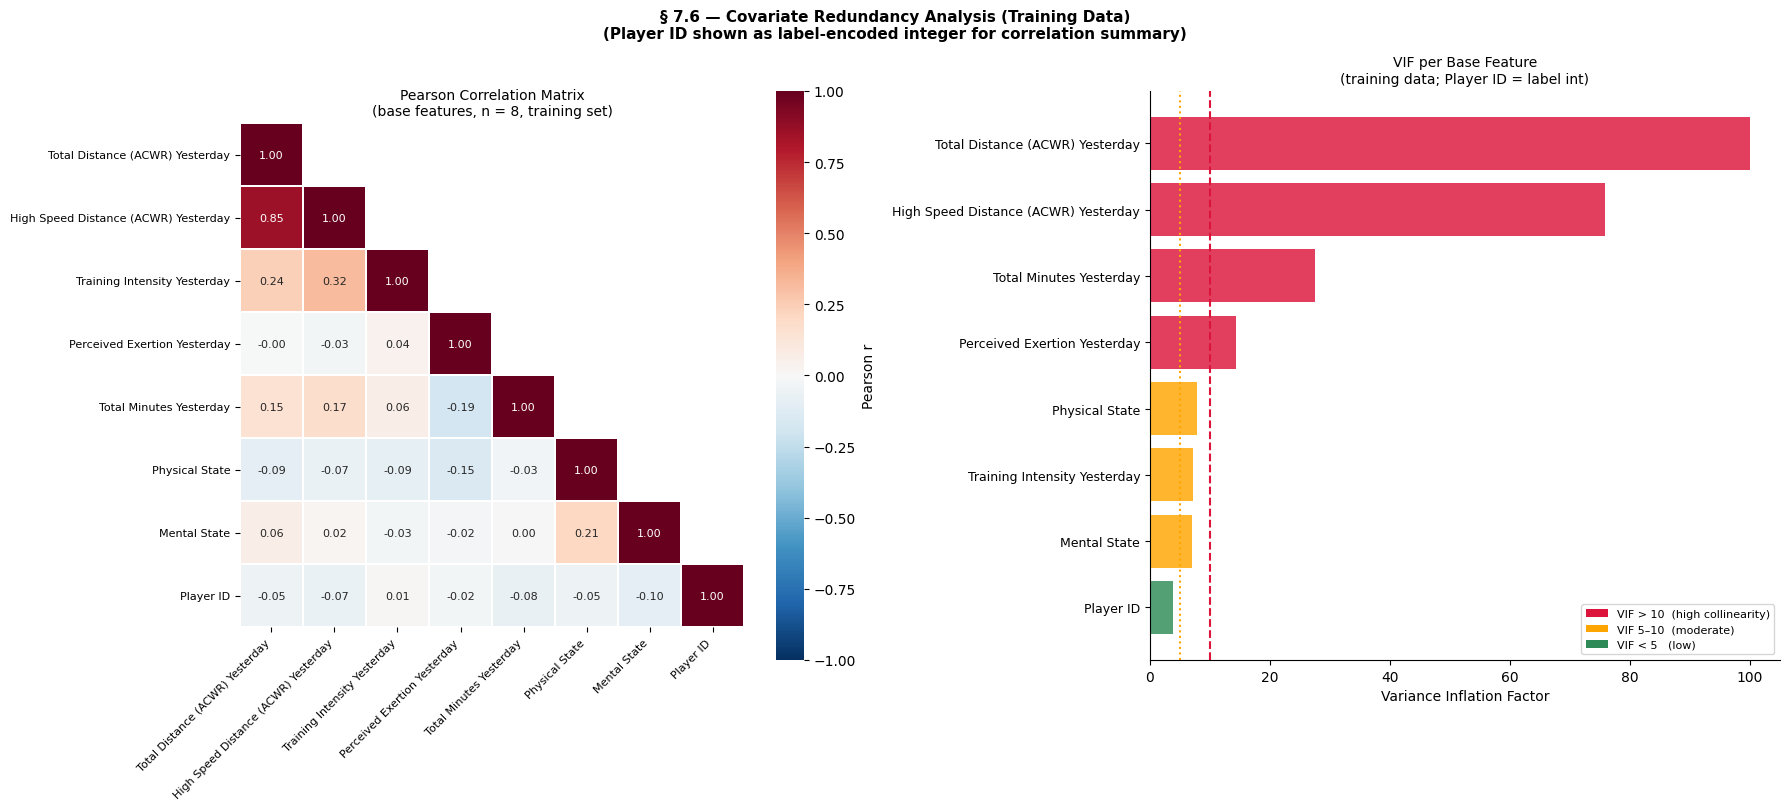


=== Highly Correlated Feature Pairs (|r| > 0.70) ===
  Total Distance (ACWR) Yesterday  ↔  High Speed Distance (ACWR) Yesterday:  r = 0.852

Highly correlated features carry redundant information. Pruning one from each pair is unlikely to hurt predictive performance.


In [78]:
# ── § 7.6 Covariate Redundancy Analysis ──────────────────────────────────────
# Part A: Pearson correlation matrix between base features (training data)
# Part B: Variance Inflation Factor (VIF) — detects multicollinearity
#
# Note on Player ID:
#   Player ID was one-hot encoded (28 binary indicators) in § 7.1.
#   Including 28 binary columns in a Pearson correlation matrix is noisy and
#   not meaningful for a redundancy check (each indicator only ever equals 0 or 1).
#   Instead, we load a separate label-encoded version of Player ID (integer 0-27)
#   for the correlation analysis — this represents the identity in a single column
#   and gives a sensible correlation with the other continuous covariates.
print('=== § 7.6 — Covariate Redundancy Analysis ===\n')

# ── Load a label-encoded version of the training data for redundancy analysis ─
loader_r = ReadinessDataLoader()
data_r = loader_r.create_dataset(
    target_variable='Match Intensity Yesterday',
    predictory_columns=COVARIATES,
    lag=best_tfn_lag,
    target_horizon=1,
    test_size=0.2,
    val_size=0.1,
    categorical_encoding='label',   # label-encode so Player ID is 1 integer column
    standardize=False,
    missing_numeric='mean',
    missing_categorical='mode',
)
train_lbl_df = data_r['X_train'].copy()
train_lbl_df.columns = data_r['feature_names']

# ── Select base (lag-0) features; these are the current-row columns, no _t-k ──
base_feat_cols_r = [f for f in data_r['feature_names']
                    if not re.search(r'_t-\d+$', f)]
if len(base_feat_cols_r) < 2:
    base_feat_cols_r = list(data_r['feature_names'])

print(f'Base features for redundancy analysis ({len(base_feat_cols_r)}):')
for c in base_feat_cols_r:
    print(f'  {c}')
print(f'\n(Player ID = label-encoded integer 0-{train_lbl_df["Player ID"].max():.0f}'
      f' for correlation purposes only — NOT used as a numeric feature in TabPFN)')

corr_mat_r = train_lbl_df[base_feat_cols_r].corr(method='pearson')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(base_feat_cols_r) * 0.75 + 2)))
fig.suptitle('§ 7.6 — Covariate Redundancy Analysis (Training Data)\n'
             '(Player ID shown as label-encoded integer for correlation summary)',
             fontsize=11, fontweight='bold')

# Panel A: Correlation heatmap (lower triangle only)
ax = axes[0]
mask_upper = np.triu(np.ones_like(corr_mat_r, dtype=bool), k=1)
sns.heatmap(
    corr_mat_r, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    mask=mask_upper, square=True,
    linewidths=0.35, linecolor='white',
    cbar_kws={'label': 'Pearson r'},
)
ax.set_title(f'Pearson Correlation Matrix\n'
             f'(base features, n = {len(base_feat_cols_r)}, training set)',
             fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Panel B: VIF bar chart
ax = axes[1]
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif_data = train_lbl_df[base_feat_cols_r].dropna()
    vif_vals = {}
    if len(vif_data) > len(base_feat_cols_r) + 1:
        for i, col in enumerate(base_feat_cols_r):
            try:
                vif_vals[col] = min(variance_inflation_factor(vif_data.values, i), 100.0)
            except Exception:
                vif_vals[col] = np.nan

    vif_s = pd.Series(vif_vals).sort_values(ascending=False)
    print('\n=== Variance Inflation Factors (VIF) ===')
    print('VIF > 10: high multicollinearity  |  VIF > 5: moderate  |  VIF < 5: low')
    print('Note: Player ID is a nominal category — its VIF has a different interpretation')
    print('      (high VIF for Player ID reflects that it is correlated with other features,')
    print('       not that its integer encoding implies ordinal multicollinearity.)\n')
    for feat_v, val_v in vif_s.items():
        flag = '  ⚠ HIGH' if val_v > 10 else ('  ▲ mod.' if val_v > 5 else '')
        pid_flag = '  [nominal — see note]' if 'Player ID' in feat_v else ''
        print(f'  {feat_v:52s}  VIF = {val_v:6.2f}{flag}{pid_flag}')

    colors_vif = ['crimson' if v > 10 else ('orange' if v > 5 else 'seagreen')
                  for v in vif_s.values]
    ax.barh(range(len(vif_s)), vif_s.values[::-1], color=colors_vif[::-1], alpha=0.82)
    ax.set_yticks(range(len(vif_s)))
    ax.set_yticklabels(list(vif_s.index[::-1]), fontsize=9)
    ax.axvline(10, color='crimson', linestyle='--', lw=1.5)
    ax.axvline(5,  color='orange',  linestyle=':',  lw=1.5)
    ax.set_xlabel('Variance Inflation Factor')
    ax.set_title('VIF per Base Feature\n(training data; Player ID = label int)', fontsize=10)
    legend_vif = [
        Patch(facecolor='crimson',  label='VIF > 10  (high collinearity)'),
        Patch(facecolor='orange',   label='VIF 5–10  (moderate)'),
        Patch(facecolor='seagreen', label='VIF < 5   (low)'),
    ]
    ax.legend(handles=legend_vif, fontsize=8)
except ImportError:
    ax.text(0.5, 0.5, 'statsmodels not installed.\nRun: pip install statsmodels',
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
    print('VIF skipped: statsmodels not installed. Run: pip install statsmodels')

plt.tight_layout()
plt.show()

# ── High-correlation summary ────────────────────────────────────────────────
print('\n=== Highly Correlated Feature Pairs (|r| > 0.70) ===')
high_pairs = []
cols_r = corr_mat_r.columns.tolist()
for i in range(len(cols_r)):
    for j in range(i + 1, len(cols_r)):
        r_ij = corr_mat_r.iloc[i, j]
        if abs(r_ij) > 0.70:
            high_pairs.append((cols_r[i], cols_r[j], r_ij))
if high_pairs:
    for fa, fb, r_v in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {fa}  ↔  {fb}:  r = {r_v:.3f}')
    print('\nHighly correlated features carry redundant information. '
          'Pruning one from each pair is unlikely to hurt predictive performance.')
else:
    print('  No feature pairs with |r| > 0.70 detected — low linear redundancy.')


---
## § 8 — Visualizations (Experiment A: Absolute Match Intensity)

### 8.1 Actual vs Predicted
Scatter plots for the **best-lag** configuration of each model. A perfect predictor places all points on the diagonal. A flat horizontal cloud means the model predicts near the training mean regardless of actual intensity.

### 8.2 RMSE vs Null Baseline + Pearson r
Bar charts across all 40 model×lag configurations (4 models × 10 lags):
- **Left:** test RMSE vs null baseline. Bars taller than the dashed line = worse than a constant predictor.
- **Right:** Pearson r (predicted vs actual). Hatched bars are anti-correlated.


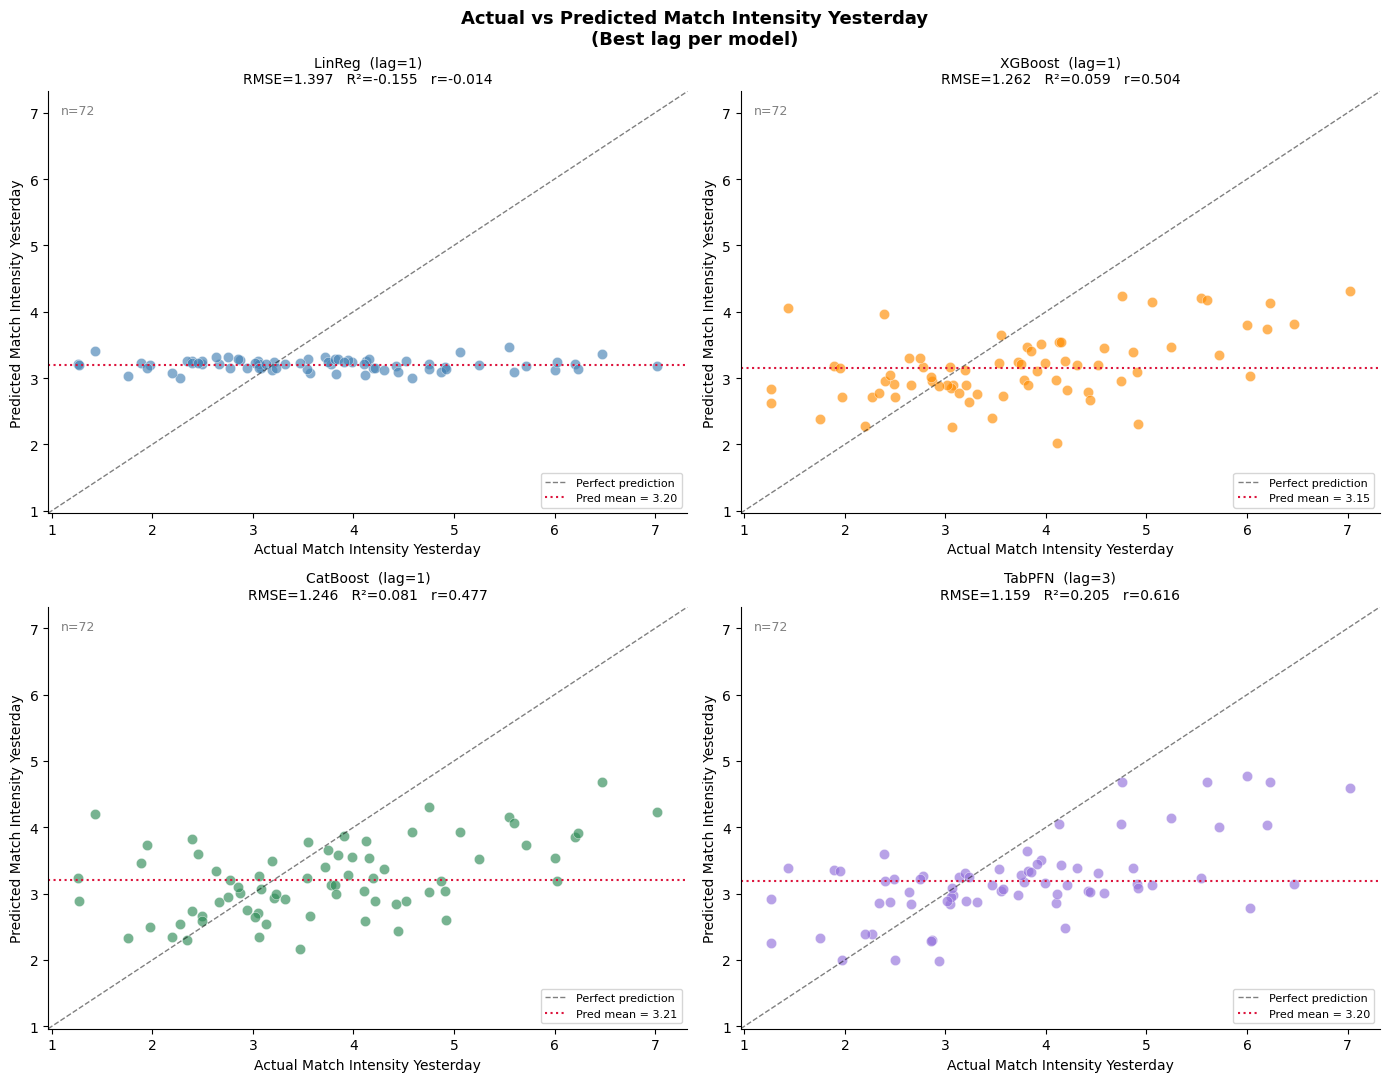


Observation: predictions cluster around the training mean.
The near-horizontal cloud is the hallmark of a near-zero-correlation predictor.


In [79]:
# ── 8.1 Actual vs Predicted ───────────────────────────────────────────────────
best_lags_all = {
    'LinReg':   min(linreg_results,  key=lambda l: linreg_results[l]['metrics']['rmse']),
    'XGBoost':  min(xgb_results,     key=lambda l: xgb_results[l]['metrics']['rmse']),
    'CatBoost': min(cat_results,     key=lambda l: cat_results[l]['metrics']['rmse']),
    'TabPFN':   min(tabpfn_results,  key=lambda l: tabpfn_results[l]['metrics']['rmse']),
}
all_res_dicts = {
    'LinReg':   linreg_results,
    'XGBoost':  xgb_results,
    'CatBoost': cat_results,
    'TabPFN':   tabpfn_results,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
fig.suptitle('Actual vs Predicted Match Intensity Yesterday\n(Best lag per model)',
             fontsize=13, fontweight='bold')

for ax, model_name in zip(axes, ['LinReg', 'XGBoost', 'CatBoost', 'TabPFN']):
    best_lag = best_lags_all[model_name]
    r = all_res_dicts[model_name][best_lag]
    y_true = r['y_test_true']
    y_pred = r['y_test_pred']
    m = r['metrics']
    color = MODEL_PALETTE[model_name]

    ax.scatter(y_true, y_pred, alpha=0.65, s=55, color=color,
               edgecolors='white', linewidths=0.4)

    lo = min(y_true.min(), y_pred.min()) - 0.3
    hi = max(y_true.max(), y_pred.max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='Perfect prediction')
    ax.axhline(y_pred.mean(), color='crimson', linestyle=':', lw=1.5,
               label=f'Pred mean = {y_pred.mean():.2f}')

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual Match Intensity Yesterday')
    ax.set_ylabel('Predicted Match Intensity Yesterday')
    ax.set_title(
        f'{model_name}  (lag={best_lag})\n'
        f'RMSE={m["rmse"]:.3f}   R²={m["r2"]:.3f}   r={m["pearson_r"]:.3f}',
        fontsize=10)
    ax.legend(fontsize=8)
    ax.text(0.02, 0.97, f'n={len(y_true)}', transform=ax.transAxes,
            va='top', fontsize=9, color='grey')

plt.tight_layout()
plt.show()

print('\nObservation: predictions cluster around the training mean.')
print('The near-horizontal cloud is the hallmark of a near-zero-correlation predictor.')

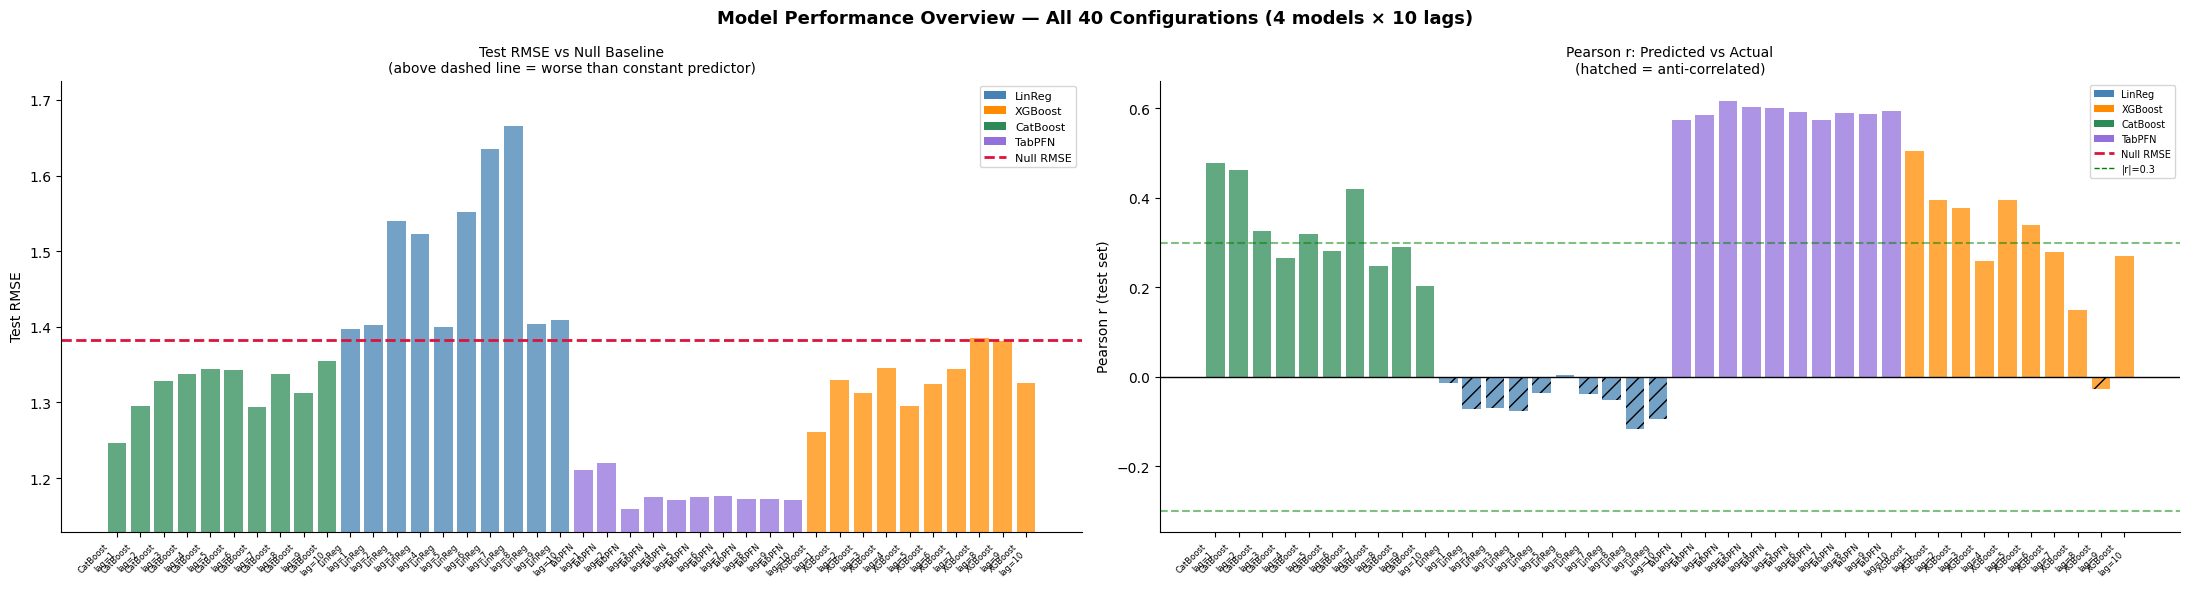


=== Best Configuration per Model (lowest Test RMSE) ===
   Model  Best Lag  Test RMSE  Null RMSE  RMSE − Null      R²  Pearson r
  LinReg         1     1.3974      1.382       0.0154 -0.1548    -0.0138
 XGBoost         1     1.2616      1.382      -0.1203  0.0586     0.5035
CatBoost         1     1.2464      1.382      -0.1356  0.0813     0.4769
  TabPFN         3     1.1592      1.382      -0.2228  0.2053     0.6160


In [80]:
# ── 8.2 RMSE vs Null Baseline + Pearson r ────────────────────────────────────
rows_viz = []
for model_name, res_dict in all_res_dicts.items():
    for lag, r in res_dict.items():
        m = r['metrics']
        rows_viz.append({
            'Model': model_name,
            'Lag': lag,
            'Label': f'{model_name}\nlag={lag}',
            'RMSE': m['rmse'],
            'Null RMSE': m['null_rmse'],
            'Pearson r': m['pearson_r'],
            'R²': m['r2'],
        })

viz_df = pd.DataFrame(rows_viz).sort_values(['Model', 'Lag']).reset_index(drop=True)
null_val = viz_df['Null RMSE'].iloc[0]
x = np.arange(len(viz_df))
bar_cols_viz = [MODEL_PALETTE[m] for m in viz_df['Model']]

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
fig.suptitle('Model Performance Overview — All 40 Configurations (4 models × 10 lags)',
             fontsize=13, fontweight='bold')

# Left: RMSE
ax = axes[0]
ax.bar(x, viz_df['RMSE'], color=bar_cols_viz, alpha=0.75)
ax.axhline(null_val, color='crimson', linestyle='--', lw=2,
           label=f'Null RMSE = {null_val:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(viz_df['Label'], rotation=45, ha='right', fontsize=6)
ax.set_ylabel('Test RMSE')
ax.set_title('Test RMSE vs Null Baseline\n(above dashed line = worse than constant predictor)', fontsize=10)
legend_els_viz = [Patch(facecolor=c, label=m) for m, c in MODEL_PALETTE.items()]
legend_els_viz.append(plt.Line2D([0], [0], color='crimson', linestyle='--', lw=2, label='Null RMSE'))
ax.legend(handles=legend_els_viz, fontsize=8)
ax.set_ylim(viz_df['RMSE'].min() - 0.03, viz_df['RMSE'].max() + 0.06)

# Right: Pearson r
ax = axes[1]
r_vals = viz_df['Pearson r'].values
bars_r = ax.bar(x, r_vals, color=bar_cols_viz, alpha=0.75)
for bar, v in zip(bars_r, r_vals):
    if v < 0:
        bar.set_hatch('//')
ax.axhline(0, color='black', lw=1)
ax.axhline(0.3,  color='green', linestyle='--', alpha=0.5, label='|r|=0.3')
ax.axhline(-0.3, color='green', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(viz_df['Label'], rotation=45, ha='right', fontsize=6)
ax.set_ylabel('Pearson r (test set)')
ax.set_title('Pearson r: Predicted vs Actual\n(hatched = anti-correlated)', fontsize=10)
ax.legend(handles=legend_els_viz + [plt.Line2D([0],[0], color='green', linestyle='--', lw=1, label='|r|=0.3')],
          fontsize=7)

plt.tight_layout()
plt.show()

print('\n=== Best Configuration per Model (lowest Test RMSE) ===')
best_rows_final = []
for model_name, res_dict in all_res_dicts.items():
    bl = min(res_dict, key=lambda l: res_dict[l]['metrics']['rmse'])
    m = res_dict[bl]['metrics']
    best_rows_final.append({
        'Model': model_name, 'Best Lag': bl,
        'Test RMSE': round(m['rmse'], 4), 'Null RMSE': round(m['null_rmse'], 4),
        'RMSE − Null': round(m['rmse'] - m['null_rmse'], 4),
        'R²': round(m['r2'], 4), 'Pearson r': round(m['pearson_r'], 4),
    })
print(pd.DataFrame(best_rows_final).to_string(index=False))

---
## § 9 — Diagnosis: Why Results Are Poor

All four models perform **worse than the null baseline** (R² < 0, RMSE > Null RMSE). This is not a software bug — it reflects five structural data problems.

---

### 1. Key features are nearly completely missing on match-event rows

The model predicts `Match Intensity Yesterday` — only non-null the day *after* a match. On those specific rows:
- **Physical State** and **Mental State** are ≈78% NaN: players don't fill the wellness questionnaire on match days
- **Perceived Exertion Yesterday** is ≈82% NaN: RPE is only filled after training sessions, not after matches
- After mean imputation, these features revert to the training-set mean — carrying **zero information**

---

### 2. Feature–target correlations are near zero

Even on rows where values are available, Pearson |r| < 0.20 for all covariates. Training load metrics from preceding days do not predict next-match performance.

---

### 3. Between-player variance dominates

Match intensity varies far more *between* players than *within* any player across matches. The model sees a mix of high-intensity wingers and lower-intensity defenders without sufficient player-specific context after mean imputation.

---

### 4. Small effective sample size

After lag construction and filtering to non-NaN target rows, the training set contains a few hundred observations — insufficient for reliable generalisation with the current covariate set.

---

### 5. Temporal train/test distribution shift

The test set (latest 20% of dates) has a systematically higher mean match intensity than the training set. A model trained on lower-intensity early-season data will systematically underpredict late-season performance → R² < 0 even with a well-fitted model.
